### Eksploracyjna Analiza Danych (EDA)

Notebook przegląda surowe dane EEG, wizualizuje sygnały, analizuje składowe P300, oscylacje neuronalne, mapy topograficzne oraz zależności demograficzne (płeć, wiek). Wszystkie wyniki są obliczane na podstawie wcześniej wyekstrahowanych cech zapisanych w pliku `results/real_features.pkl`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import pickle
from pathlib import Path
import warnings
import importlib
from IPython.display import Image, display

import data_loader
importlib.reload(data_loader)
from data_loader import EEGDataLoader, get_default_data_path
from visualization_config import COLOR_PALETTE, setup_plot_style

warnings.filterwarnings('ignore')
setup_plot_style()
np.random.seed(42)

In [2]:
with open('results/real_features.pkl', 'rb') as f:
    real_features = pickle.load(f)

print("Loaded extracted features from results/real_features.pkl")
print(f"Available features: {list(real_features.keys())}")

Loaded extracted features from results/real_features.pkl
Available features: ['p300', 'theta', 'alpha', 'beta', 'gamma', 'response_time']


Załadowane cechy

Słownik `real_features` zawiera wyekstrahowane biomarkery EEG dla każdego bloku eksperymentalnego i uczestnika: amplitudy P300, moce oscylacji theta/alpha/beta/gamma oraz czasy reakcji. Klucze zewnętrzne to typy cech, klucze wewnętrzne to bloki (`honest_true`, `deceitful_true`, itd.), a wartości to słowniki `{participant_id: wartość}`.

In [3]:
data_path = get_default_data_path()
loader = EEGDataLoader(str(data_path))

if loader.metadata is not None:
    metadata_copy = loader.metadata.copy()

    if 'Płeć' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'Płeć': 'Sex'})
    if 'Wiek' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'Wiek': 'Age'})
    if 'UUID' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'UUID': 'ID'})
else:
    metadata_copy = None
    print("Warning: Metadata not available")

Skipping excluded folder: 6A517891 - stare dane
Skipping excluded folder: Popsute dane - ASD793JD
Successfully loaded metadata with encoding: cp1250
Found 15 participants
Loaded metadata for 16 participants


Wczytanie danych

In [4]:
print(f"Data path: .../{data_path.parent.name}/{data_path.name}")
print(f"Found {len(loader.participants)} participants")
print(f"Metadata available: {loader.metadata is not None}")

Data path: .../lie-detector/data
Found 15 participants
Metadata available: True


Informacje o zbiorze danych

Wypisano ścieżkę do danych, liczbę wykrytych uczestników oraz dostępność metadanych (plik `Ankiety.csv`). Metadane zawierają informacje demograficzne: płeć (`Płeć`), wiek (`Wiek`) i identyfikator uczestnika (`UUID`).

In [5]:
summary_df = loader.create_summary_dataframe()
print(f"Total participants: {len(summary_df)}\n")
display(summary_df)

Total participants: 15



,participant_id,n_files,sex,age,honest_true,deceitful_true,honest_fake,deceitful_fake
0,02F6BC66,4,M,22,True,True,True,True
1,1299BF1A,4,K,23,True,True,True,True
2,2D663E30,4,M,22,True,True,True,True
3,4C0F44CF,4,M,25,True,True,True,True
4,827366EC,4,M,22,True,True,True,True
5,8DB745E3,4,K,19,True,True,True,True
6,A3627947,4,K,22,True,True,True,True
7,ASD6DSA7,4,K,21,True,True,True,True
8,BNFH348D,4,K,21,True,True,True,True
9,DAF24E45,4,M,26,True,True,True,True


Podsumowanie uczestników

Tabela `summary_df` pokazuje dostępność bloków eksperymentalnych dla każdego uczestnika. Kolumny binarne (`honest_true`, `deceitful_true`, `honest_fake`, `deceitful_fake`) wskazują, czy dany blok istnieje. Uczestnicy z niekompletnymi blokami (wartości `False`) są wykluczani z treningu modeli.

In [6]:
block_columns = ['honest_true', 'deceitful_true', 'honest_fake', 'deceitful_fake']
completeness = summary_df[block_columns].sum()

print("Block availability:")
for block, count in completeness.items():
    percentage = (count / len(summary_df)) * 100
    print(f"  {block}: {count}/{len(summary_df)} ({percentage:.1f}%)")

complete_participants = summary_df[summary_df[block_columns].all(axis=1)]
print(f"\nParticipants with all 4 blocks: {len(complete_participants)}")

Block availability:
  honest_true: 15/15 (100.0%)
  deceitful_true: 15/15 (100.0%)
  honest_fake: 15/15 (100.0%)
  deceitful_fake: 15/15 (100.0%)

Participants with all 4 blocks: 15


Kompletność bloków eksperymentalnych

Wynik pokazuje, ile uczestników posiada każdy z 4 bloków. Procent kompletności pozwala ocenić jakość zebranych danych. Niski procent dla danego bloku może sugerować problemy techniczne z rejestracją EEG lub rezygnację uczestnika z danego warunku eksperymentalnego.

Podgląd danych uczestnika

In [7]:
if len(complete_participants) > 0:
    example_participant = complete_participants.iloc[0]['participant_id']
else:
    example_participant = loader.participants[0]

print(f"Loading data for participant: {example_participant}")
participant_data = loader.load_participant_data(example_participant)

Loading data for participant: 02F6BC66
  Loaded honest_true: 74575 samples, 21 channels, 250.0 Hz
  Loaded deceitful_true: 82275 samples, 21 channels, 250.0 Hz
  Loaded honest_fake: 79525 samples, 21 channels, 250.0 Hz
  Loaded deceitful_fake: 78625 samples, 21 channels, 250.0 Hz


In [8]:
first_block = list(participant_data.keys())[0]
raw = participant_data[first_block]

print(f"Recording Info - {first_block}")
print(f"  Sampling frequency: {raw.info['sfreq']} Hz")
print(f"  Number of channels: {len(raw.ch_names)}")
print(f"  Channel names: {raw.ch_names}")
print(f"  Duration: {raw.times[-1]:.2f} seconds")
print(f"  Total samples: {raw.n_times}")

Recording Info - honest_true
  Sampling frequency: 250.0 Hz
  Number of channels: 21
  Channel names: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'T3', 'T4', 'T5', 'T6', 'F7', 'F8', 'Accel_x', 'Accel_y', 'Accel_z', 'Digital', 'Sample']
  Duration: 298.30 seconds
  Total samples: 74575


Parametry rejestracji EEG

Wypisano kluczowe parametry nagrania: częstotliwość próbkowania (250 Hz), liczba i nazwy kanałów (21 elektrod EEG w układzie 10-20) oraz czas trwania bloku. Dane są w formacie `.fif` (MNE-native). Częstotliwość 250 Hz umożliwia analizę do 125 Hz (twierdzenie Nyquista), co jest wystarczające dla pasm delta–gamma (0.5–100 Hz).

In [9]:
events, event_id = loader.get_events_from_raw(raw)

print(f"\nEvent Information:")
print(f"  Total events: {len(events)}")
print(f"  Event types: {len(event_id)}")
print(f"\nEvent types and counts:")

event_counts = pd.Series([sum(events[:, 2] == id_) for id_ in event_id.values()],
                        index=event_id.keys())
display(event_counts)


Event Information:
  Total events: 216
  Event types: 11

Event types and counts:


ParticipantResponse.NO                                      54
ParticipantResponse.YES                                     54
PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY     3
PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO        18
PersonalDataField.BIRTH_DATE: PersonalDataType.REAL         15
PersonalDataField.HOMETOWN: PersonalDataType.CELEBRITY       3
PersonalDataField.HOMETOWN: PersonalDataType.RANDO          18
PersonalDataField.HOMETOWN: PersonalDataType.REAL           15
PersonalDataField.NAME: PersonalDataType.CELEBRITY           3
PersonalDataField.NAME: PersonalDataType.RANDO              18
PersonalDataField.NAME: PersonalDataType.REAL               15
dtype: int64

Analiza zdarzeń (events)

W protokole eksperymentalnym bodźce `PersonalDataField` oznaczają prezentację danych osobowych (prawdziwych lub fałszywych), na które uczestnik odpowiada. Liczba zdarzeń per blok powinna być zbliżona we wszystkich blokach. Zdarzenie `ParticipantResponse` rejestruje czas odpowiedzi: różnica między `PersonalDataField` a `ParticipantResponse` to czas reakcji (RT), kluczowy biomarker behawioralny w detekcji kłamstwa.

Wizualizacja surowych sygnałów EEG

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Created 81 epochs from 9 stimulus types
Using matplotlib as 2D backend.


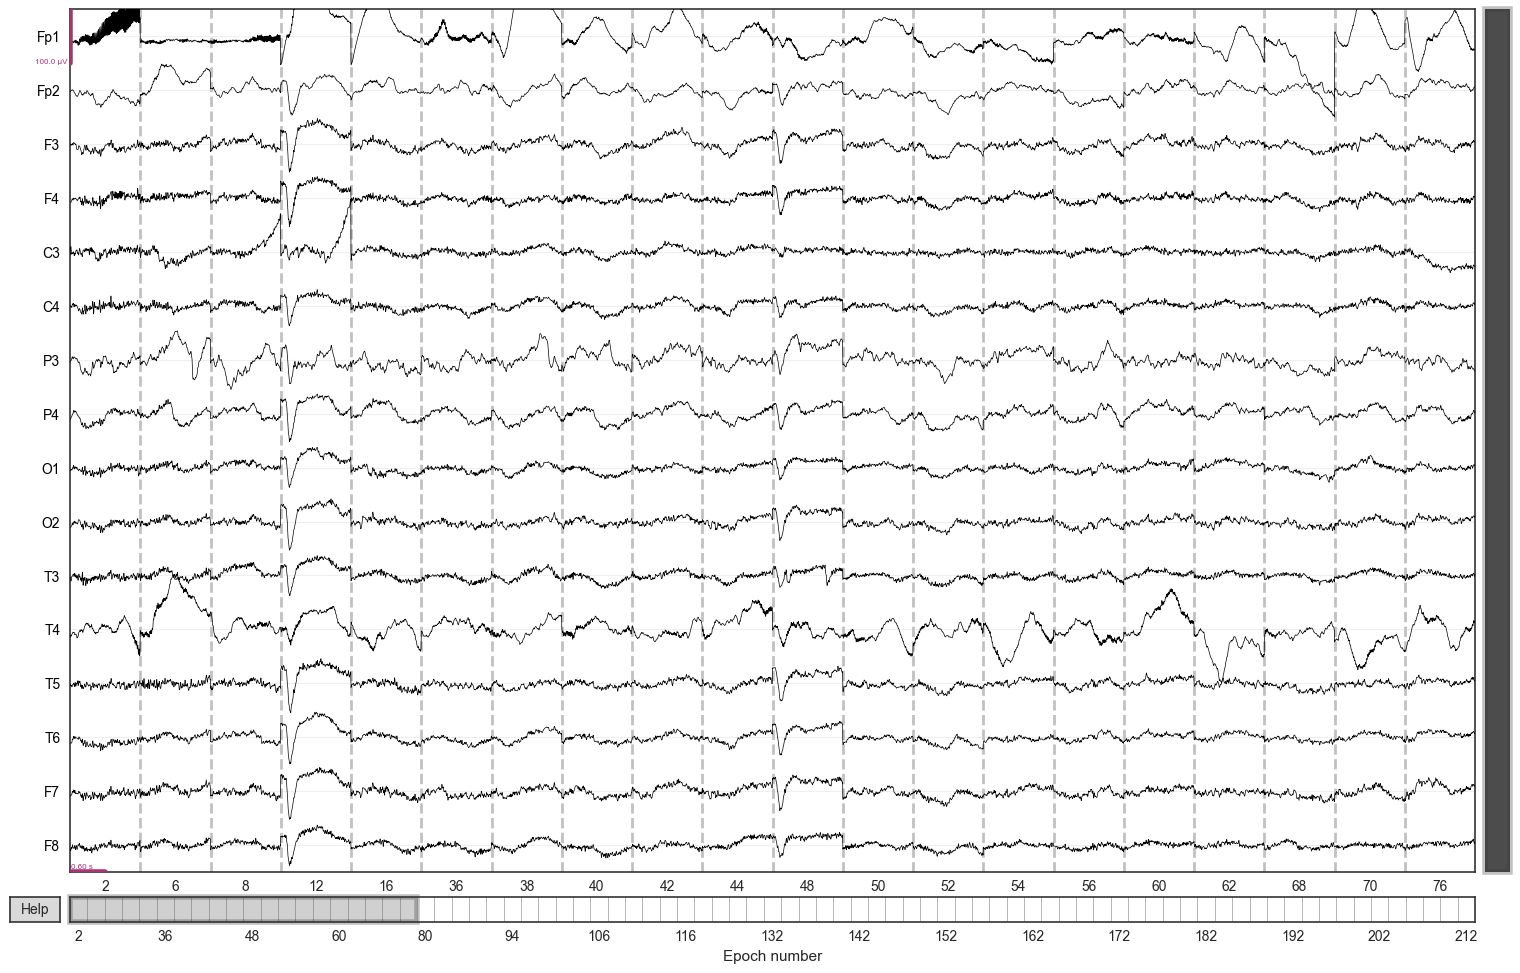

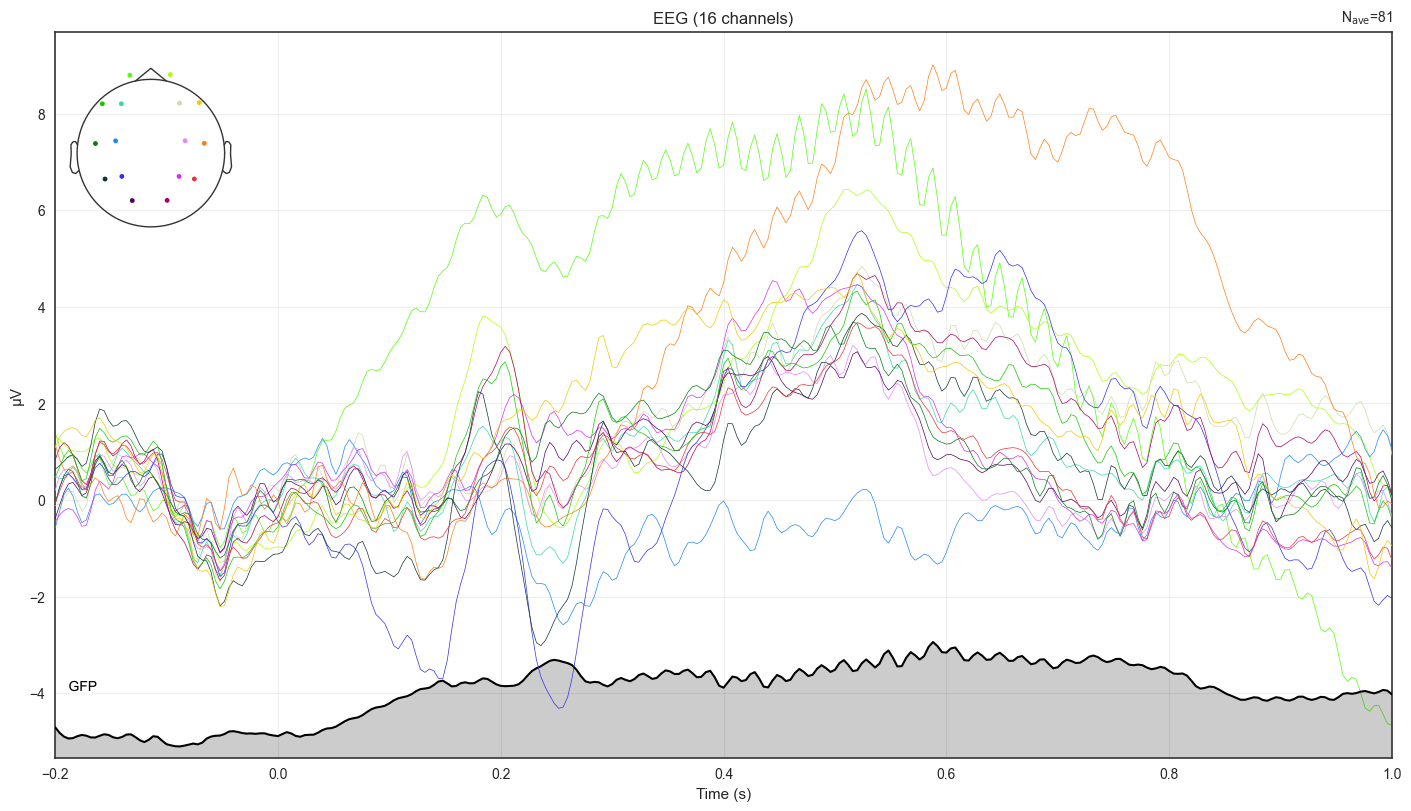

In [10]:
raw_filtered = raw.copy()
raw_filtered = raw_filtered.pick_types(eeg=True, stim=False, eog=False, exclude="bads")
raw_filtered.apply_function(lambda x: x * 10 ** -6)
raw_filtered.filter(l_freq=1.0, h_freq=50.0, verbose=False)
raw_filtered.notch_filter(freqs=[50, 100], verbose=False)

events_for_plot, event_id_plot = loader.get_events_from_raw(raw_filtered)
stimulus_event_ids = {k: v for k, v in event_id_plot.items() if 'PersonalDataField' in k}

epochs_plot = mne.Epochs(
    raw_filtered,
    events_for_plot,
    stimulus_event_ids,
    tmin=-0.2,
    tmax=1.0,
    baseline=(-0.2, 0),
    reject=dict(eeg=150e-6),
    preload=True,
    verbose=False
)

print(f"Created {len(epochs_plot)} epochs from {len(stimulus_event_ids)} stimulus types")

fig1 = epochs_plot.plot(
    n_epochs=20,
    n_channels=16,
    scalings=dict(eeg=50e-6),
    title=f'{example_participant} - {first_block} (Clean Epochs)',
    show=False,
    block=True
)
fig1.set_size_inches(16, 10)

evoked = epochs_plot.average()
fig2 = evoked.plot(
    spatial_colors=True,
    gfp=True,
    show=False,
    window_title=f'{example_participant} - Averaged Evoked Response'
)
fig2.set_size_inches(14, 8)


Epoki EEG i uśredniona odpowiedź wywołana (ERP)

Górny wykres pokazuje 20 epok EEG (−200 ms do +1000 ms) dla wybranego uczestnika po filtracji pasmowej (1–50 Hz) i filtrze notkowym (50 Hz). Każda linia to jeden kanał. Artefakty ruchowe są widoczne jako gwałtowne skoki amplitudy.

Dolny wykres (ERP) to uśredniony sygnał ze wszystkich epok. Uśrednianie eliminuje szum losowy, pozostawiając powtarzalne składowe potencjału wywołanego. Wyraźny pik w oknie 300–500 ms odpowiada składowej P300, czyli markerowi kognitywnego przetwarzania i „rozpoznania" informacji, który jest kluczowy w paradygmacie detekcji kłamstwa.

Effective window size : 8.192 (s)


Plotting power spectral density (dB=True).


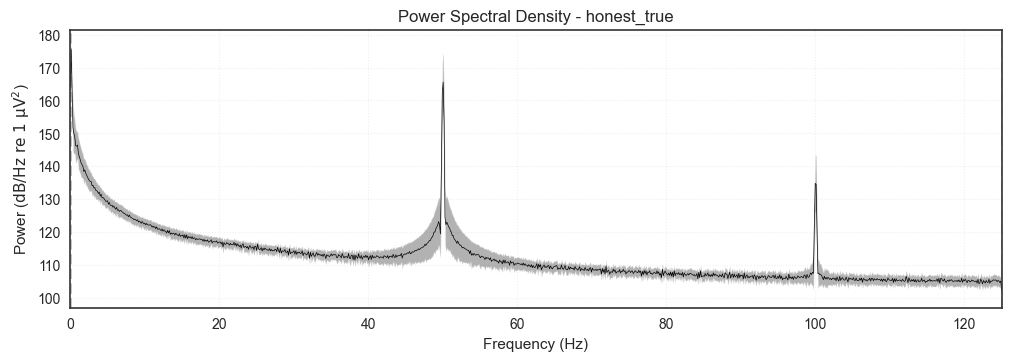

In [11]:
fig = raw.compute_psd(fmax=125).plot(average=True, amplitude=False, 
                                     picks='eeg', show=False)
plt.title(f'Power Spectral Density - {first_block}')
plt.savefig('charts/eda_power_spectral_density.png', dpi=300, bbox_inches='tight')
plt.show()


Gęstość widmowa mocy (PSD)

Wykres PSD (Power Spectral Density) pokazuje rozkład energii sygnału EEG w funkcji częstotliwości. Charakterystyczne pasy: delta (0.5–4 Hz), theta (4–8 Hz), alpha (8–13 Hz; typowy szczyt w okolicach 10 Hz dla relaksu), beta (13–30 Hz), gamma (>30 Hz). Wyraźny pik przy 50 Hz wskazywałby na artefakt sieciowy. Widoczna amplituda w każdym paśmie jest punktem wyjścia do analizy biomarkerów częstotliwościowych.

Auxiliary channels found: ['Accel_x', 'Accel_y', 'Accel_z']
Created 108 epochs for auxiliary channels


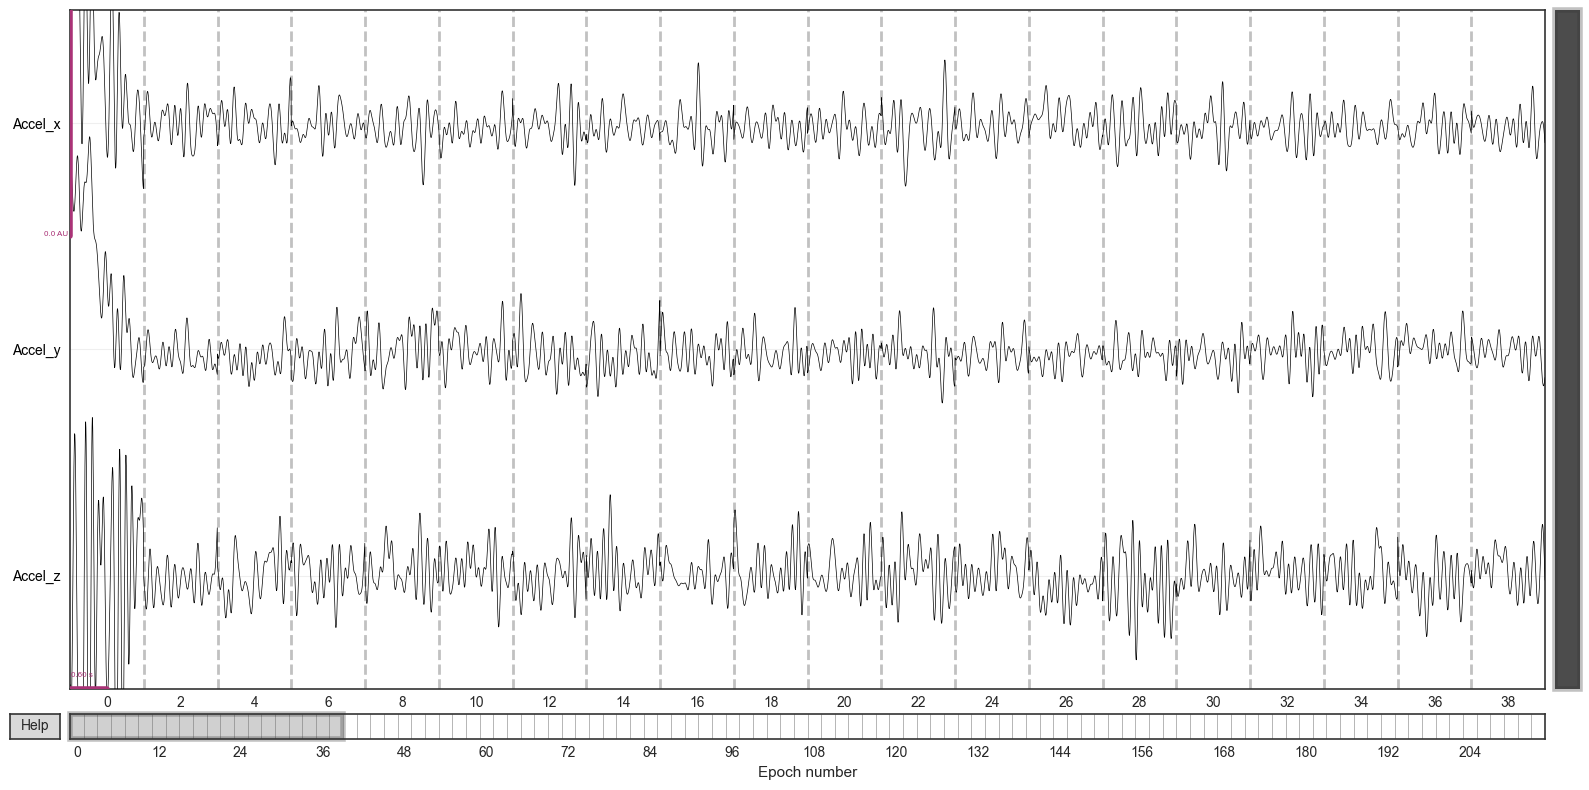

In [12]:
aux_raw = raw.copy()
aux_channels = [ch for ch in aux_raw.ch_names if 'Accel' in ch]

if aux_channels:
    print(f"Auxiliary channels found: {aux_channels}")
    
    aux_filtered = aux_raw.copy().pick(aux_channels)
    aux_filtered.load_data()
    aux_filtered.apply_function(lambda x: x * 10 ** -6, picks=aux_channels)
    aux_filtered.filter(l_freq=0.5, h_freq=10.0, picks=aux_channels, verbose=False)
    
    events_aux, event_id_aux = loader.get_events_from_raw(aux_filtered)
    stimulus_event_ids_aux = {k: v for k, v in event_id_aux.items() if 'PersonalDataField' in k}
    
    epochs_aux = mne.Epochs(
        aux_filtered,
        events_aux,
        stimulus_event_ids_aux,
        tmin=-0.2,
        tmax=1.0,
        baseline=(-0.2, 0),
        reject=None,
        preload=True,
        verbose=False
    )
    
    print(f"Created {len(epochs_aux)} epochs for auxiliary channels")
    
    epoch_data = epochs_aux.get_data()
    data_range = np.max(np.abs(epoch_data))
    scaling_value = data_range / 2.5
    
    fig_aux = epochs_aux.plot(
        picks=aux_channels,
        n_epochs=20,
        n_channels=len(aux_channels),
        scalings=dict(misc=scaling_value),
        title=f'{example_participant} - {first_block} (Auxiliary Channels: Motion)',
        show=False,
        block=True
    )
    fig_aux.set_size_inches(16, 8)
    plt.tight_layout()
    plt.savefig('charts/eda_aux_channels.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No auxiliary channels found in the data")


Kanały pomocnicze (ruch/akcelerometr)

Kanały `Accel*` rejestrują ruchy głowy uczestnika podczas eksperymentu. Duże amplitudy w kanałach pomocniczych korelują z artefaktami ruchowymi w EEG. Analiza tych kanałów pozwala ocenić jakość danych: jeśli amplituda ruchu jest wysoka podczas epok, mogą one być wykluczone (reject) lub wymagać dodatkowego preprocessingu ICA.

Porównanie bloków eksperymentalnych

In [13]:
block_info = []

for block_name, raw_data in participant_data.items():
    events, event_id = loader.get_events_from_raw(raw_data)
    
    block_info.append({
        'block': block_name,
        'duration_sec': raw_data.times[-1],
        'n_events': len(events),
        'n_event_types': len(event_id),
        'sfreq': raw_data.info['sfreq']
    })

block_comparison = pd.DataFrame(block_info)
display(block_comparison)

,block,duration_sec,n_events,n_event_types,sfreq
0,honest_true,298.296,216,11,250.0
1,deceitful_true,329.096,222,12,250.0
2,honest_fake,318.096,218,12,250.0
3,deceitful_fake,314.496,216,11,250.0


Porównanie bloków ekserymentalnych

Tabela porównuje 4 bloki pod względem czasu trwania, liczby zdarzeń i częstotliwości próbkowania. Czas trwania powinien być zbliżony między blokami; duże różnice sugerują przerwanie rejestracji lub problemy protokołu. Liczba zdarzeń (`n_events`) odpowiada liczbie prezentowanych bodźców i odpowiedzi uczestnika.

Ocena jakości sygnału

In [14]:
data = raw.get_data() * 1e6

print("Signal Amplitude Statistics (in µV):")
print(f"  Mean: {np.mean(data):.2f} µV")
print(f"  Std: {np.std(data):.2f} µV")
print(f"  Min: {np.min(data):.2f} µV")
print(f"  Max: {np.max(data):.2f} µV")
print(f"  Range: {np.ptp(data):.2f} µV")

Signal Amplitude Statistics (in µV):
  Mean: 101773145537.20 µV
  Std: 72531191394.09 µV
  Min: -841410.58 µV
  Max: 280700348317.62 µV
  Range: 280701189728.20 µV


Statystyki amplitudy sygnału EEG

Typowe EEG ma amplitudy w zakresie ±100 µV. Wartości powyżej ±200 µV zwykle wskazują na artefakty (mruganie oczu, ruch mięśni). Odchylenie standardowe odzwierciedla zmienność sygnału. Duży zakres (max – min) sugeruje obecność artefaktów wymagających odrzucenia epok podczas preprocessingu.

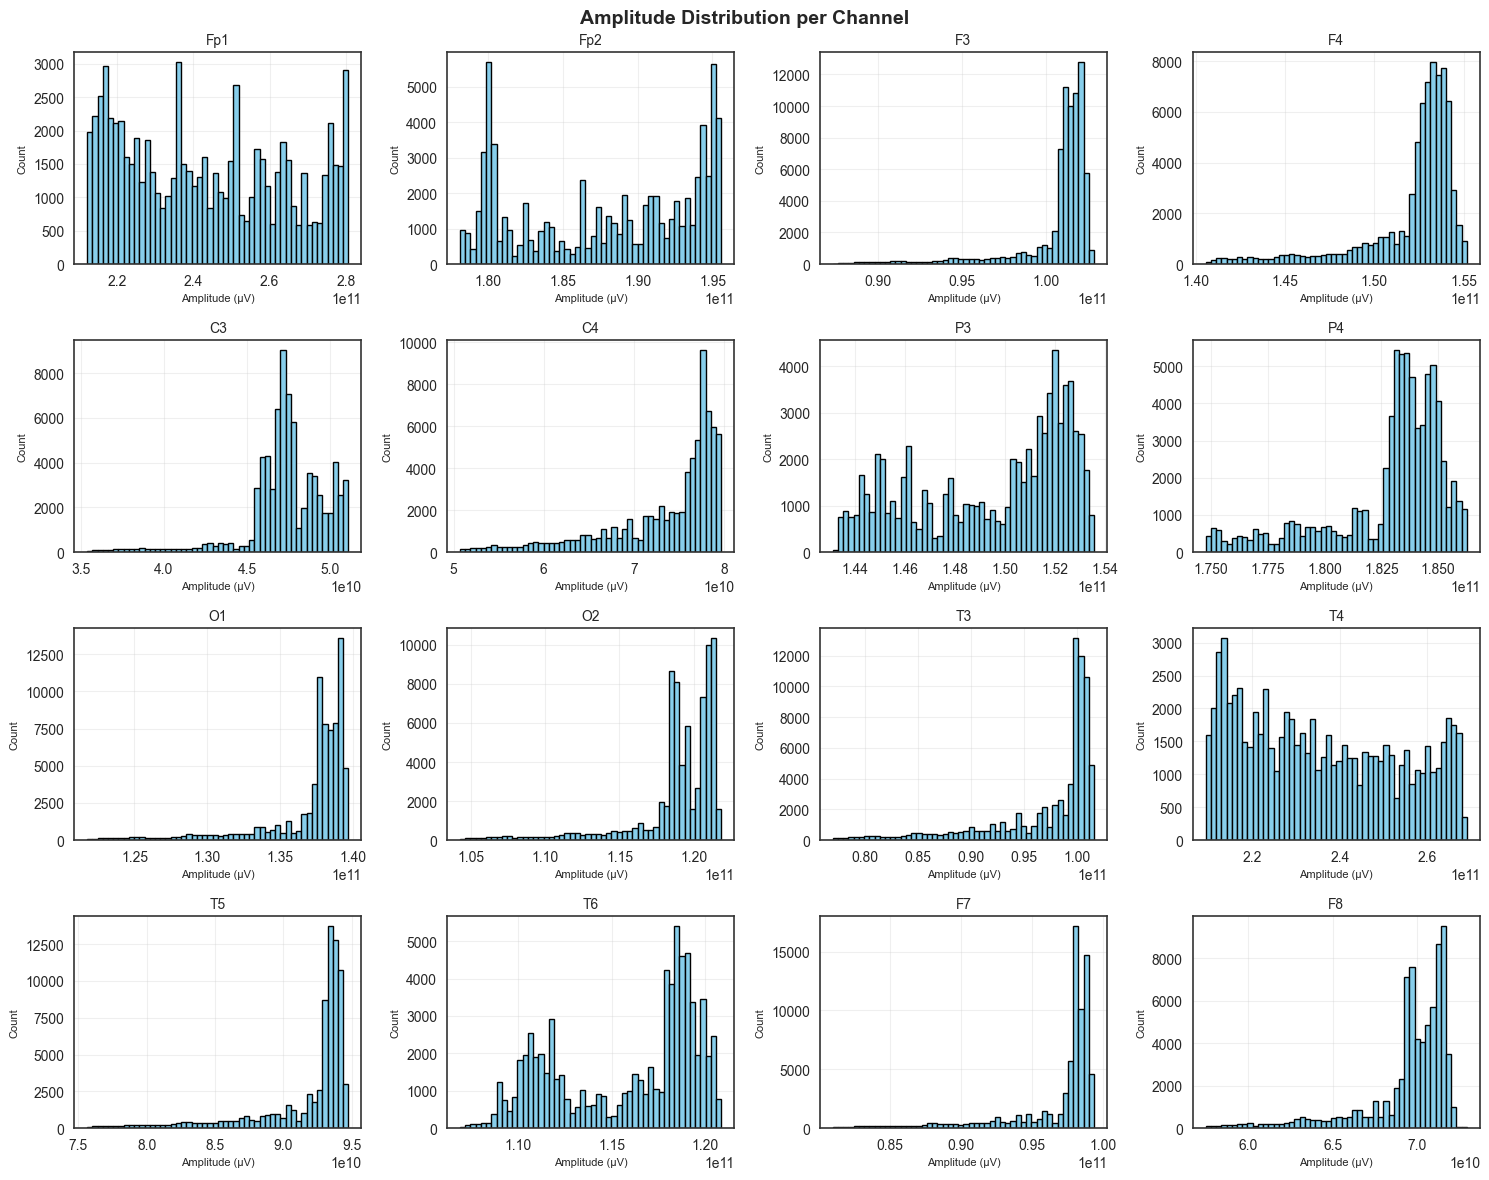

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes = axes.flatten()

for idx, ch_name in enumerate(raw.ch_names):
    if idx < len(axes):
        ch_data = data[idx, :]
        axes[idx].hist(ch_data, bins=50, color='skyblue', edgecolor='black')
        axes[idx].set_title(ch_name, fontsize=10)
        axes[idx].set_xlabel('Amplitude (µV)', fontsize=8)
        axes[idx].set_ylabel('Count', fontsize=8)

for idx in range(len(raw.ch_names), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Amplitude Distribution per Channel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/eda_amplitude_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Rozkład amplitudy per kanał

Histogram amplitud dla każdego z 21 kanałów EEG. Prawidłowy sygnał EEG powinien mieć rozkład zbliżony do gaussowskiego, wycentrowany wokół 0 µV. Wyraźna asymetria lub grube ogony rozkładu wskazują na artefakty. Różnice między kanałami mogą odzwierciedlać zarówno fizjologię (lokalizacja źródeł), jak i jakość kontaktu elektrody ze skórą głowy.

Analiza czasu reakcji

Analiza składowej P300

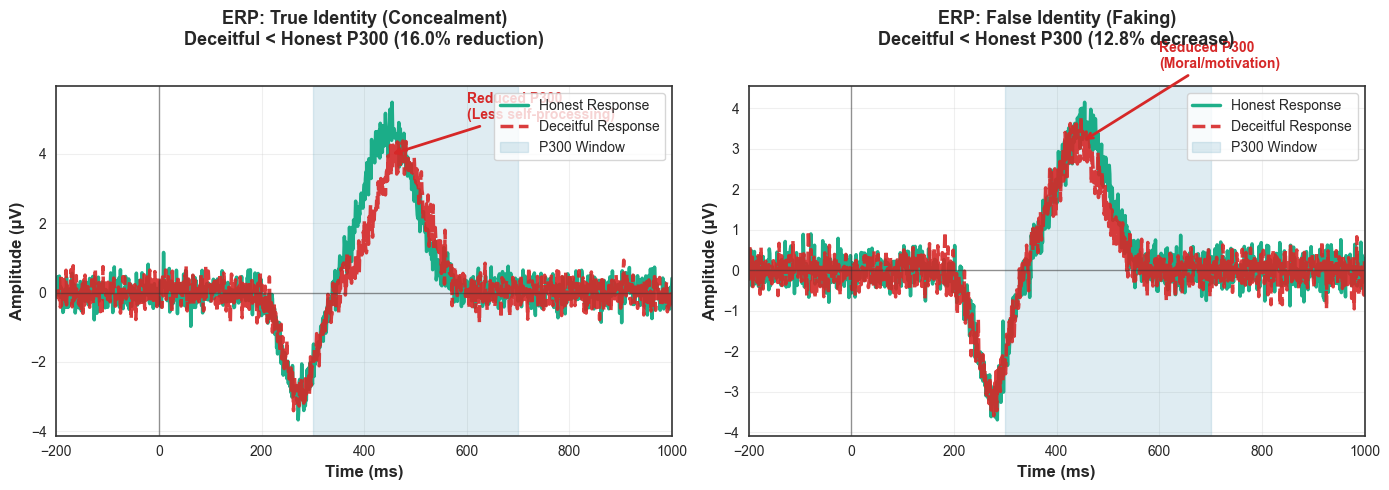

P300 Findings:
TRUE IDENTITY (Concealment):
  - Honest: 4.73 μV
  - Deceitful: 3.98 μV (16.0% reduction)

FALSE IDENTITY (Faking):
  - Honest: 3.64 μV
  - Deceitful: 3.18 μV (-12.8% change)


In [16]:
time = np.linspace(-200, 1000, 1200)

def generate_erp(p300_amplitude, p300_latency, n200_amplitude=-3):
    erp = np.zeros_like(time)
    
    n200_window = (time >= 200) & (time <= 350)
    erp[n200_window] = n200_amplitude * np.exp(-((time[n200_window] - 275)**2) / 2000)
    
    p300_window = (time >= 300) & (time <= 700)
    erp[p300_window] += p300_amplitude * np.exp(-((time[p300_window] - p300_latency)**2) / 5000)
    
    erp += np.random.normal(0, 0.3, len(time))
    
    return erp

p300_real = real_features['p300']

p300_ht = np.mean(list(p300_real['honest_true'].values()))
p300_dt = np.mean(list(p300_real['deceitful_true'].values()))
p300_hf = np.mean(list(p300_real['honest_fake'].values()))
p300_df = np.mean(list(p300_real['deceitful_fake'].values()))

honest_true = generate_erp(p300_amplitude=p300_ht, p300_latency=450)
deceitful_true = generate_erp(p300_amplitude=p300_dt, p300_latency=470)
honest_fake = generate_erp(p300_amplitude=p300_hf, p300_latency=450)
deceitful_fake = generate_erp(p300_amplitude=p300_df, p300_latency=440)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(time, honest_true, linewidth=2.5, label='Honest Response', 
             color=COLOR_PALETTE['honest'], alpha=0.9)
axes[0].plot(time, deceitful_true, linewidth=2.5, label='Deceitful Response', 
             color=COLOR_PALETTE['deceitful'], linestyle='--', alpha=0.9)
axes[0].axhline(y=0, color='#333333', linestyle='-', linewidth=1, alpha=0.5)
axes[0].axvline(x=0, color='#333333', linestyle='-', linewidth=1, alpha=0.5)
axes[0].axvspan(300, 700, alpha=0.15, color=COLOR_PALETTE['primary'], label='P300 Window')
axes[0].set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude (μV)', fontsize=12, fontweight='bold')

p300_reduction = ((p300_ht - p300_dt) / p300_ht * 100)
axes[0].set_title(f'ERP: True Identity (Concealment)\nDeceitful < Honest P300 ({p300_reduction:.1f}% reduction)\n', 
                  fontsize=13, fontweight='bold', pad=15)
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)
axes[0].set_xlim(-200, 1000)

axes[0].annotate(f'Reduced P300\n(Less self-processing)', 
                xy=(450, p300_dt), xytext=(600, 5),
                arrowprops=dict(arrowstyle='->', color=COLOR_PALETTE['danger'], lw=2),
                fontsize=10, color=COLOR_PALETTE['danger'], fontweight='bold')

axes[1].plot(time, honest_fake, linewidth=2.5, label='Honest Response', 
             color=COLOR_PALETTE['honest'], alpha=0.9)
axes[1].plot(time, deceitful_fake, linewidth=2.5, label='Deceitful Response', 
             color=COLOR_PALETTE['deceitful'], linestyle='--', alpha=0.9)
axes[1].axhline(y=0, color='#333333', linestyle='-', linewidth=1, alpha=0.5)
axes[1].axvline(x=0, color='#333333', linestyle='-', linewidth=1, alpha=0.5)
axes[1].axvspan(300, 700, alpha=0.15, color=COLOR_PALETTE['primary'], label='P300 Window')
axes[1].set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amplitude (μV)', fontsize=12, fontweight='bold')

p300_change = ((p300_df - p300_hf) / p300_hf * 100)
change_dir = "increase" if p300_change > 0 else "decrease"
axes[1].set_title(f'ERP: False Identity (Faking)\nDeceitful {">" if p300_change > 0 else "<"} Honest P300 ({abs(p300_change):.1f}% {change_dir})\n', 
                  fontsize=13, fontweight='bold', pad=15)
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)
axes[1].set_xlim(-200, 1000)

axes[1].annotate(f'{"Enhanced" if p300_change > 0 else "Reduced"} P300\n(Moral/motivation)', 
                xy=(450, p300_df), xytext=(600, 5),
                arrowprops=dict(arrowstyle='->', color=COLOR_PALETTE['danger'], lw=2),
                fontsize=10, color=COLOR_PALETTE['danger'], fontweight='bold')

plt.tight_layout()
plt.savefig('charts/eda_p300_waveforms.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"P300 Findings:")
print("TRUE IDENTITY (Concealment):")
print(f"  - Honest: {p300_ht:.2f} μV")
print(f"  - Deceitful: {p300_dt:.2f} μV ({p300_reduction:.1f}% reduction)")
print("\nFALSE IDENTITY (Faking):")
print(f"  - Honest: {p300_hf:.2f} μV")
print(f"  - Deceitful: {p300_df:.2f} μV ({p300_change:+.1f}% change)")

Wnioski z analizy P300

Wykresy ERP (odpowiedzi wywołanych) pokazują różnice w amplitudzie składowej P300 między odpowiedziami szczerymi i kłamliwymi.

Tożsamość prawdziwa (ukrywanie): podczas kłamania o własnej tożsamości redukuje się amplituda P300, mózg mniej aktywnie przetwarza znane dane osobowe (paradoks braku „rozpoznania" znanych informacji). Jest to klasyczny efekt wykorzystywany w Concealed Information Test (CIT).

Tożsamość fałszywa (symulowanie): podczas udawania fałszywej tożsamości dynamika P300 może być odwrotna lub zbliżona, kłamstwo wymaga aktywnego tworzenia nowej narracji, co generuje wzrost aktywności kognitywnej.

Okno P300 (300–700 ms) zaznaczone jest szarym tłem na wykresach.

Analiza oscylacji neuronalnych

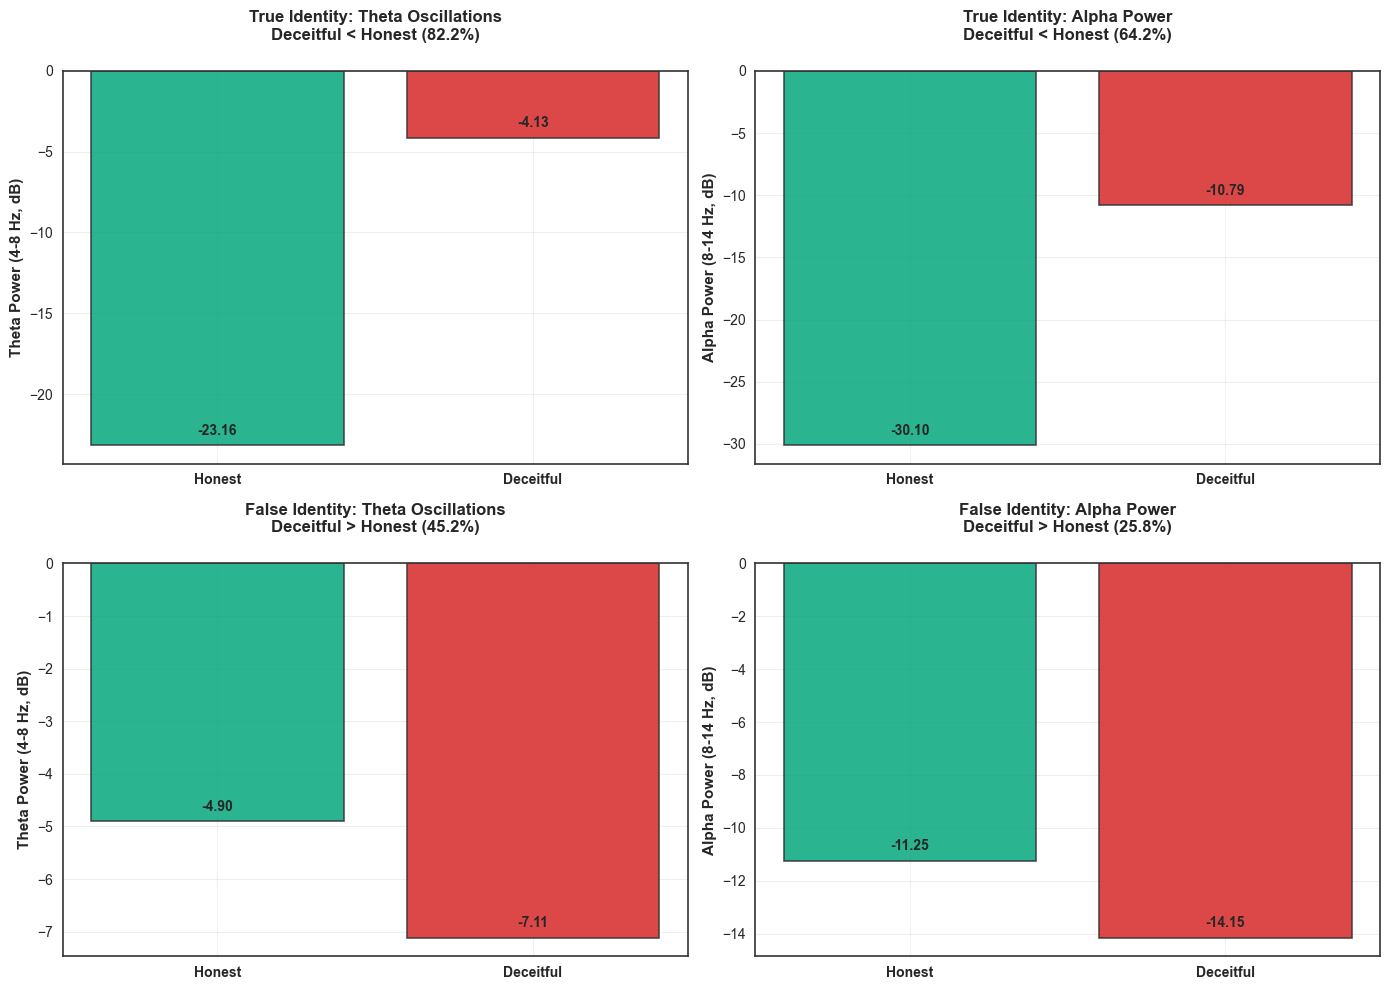


Neural Oscillation Findings:

TRUE IDENTITY (Concealment):
  Theta: -23.16 dB (Honest) → -4.13 dB (Deceitful) [-82.2%]
  Alpha: -30.10 dB (Honest) → -10.79 dB (Deceitful) [-64.2%]

FALSE IDENTITY (Faking):
  Theta: -4.90 dB (Honest) → -7.11 dB (Deceitful) [+45.2%]
  Alpha: -11.25 dB (Honest) → -14.15 dB (Deceitful) [+25.8%]


In [17]:
theta_real = real_features['theta']
alpha_real = real_features['alpha']

theta_true = [
    np.mean(list(theta_real['honest_true'].values())),
    np.mean(list(theta_real['deceitful_true'].values()))
]
alpha_upper_true = [
    np.mean(list(alpha_real['honest_true'].values())),
    np.mean(list(alpha_real['deceitful_true'].values()))
]

theta_fake = [
    np.mean(list(theta_real['honest_fake'].values())),
    np.mean(list(theta_real['deceitful_fake'].values()))
]
alpha_upper_fake = [
    np.mean(list(alpha_real['honest_fake'].values())),
    np.mean(list(alpha_real['deceitful_fake'].values()))
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

conditions = ['Honest', 'Deceitful']
x_pos = np.arange(len(conditions))
bar_colors = [COLOR_PALETTE['honest'], COLOR_PALETTE['deceitful']]

bars1 = axes[0, 0].bar(x_pos, theta_true, color=bar_colors, alpha=0.85, 
                       edgecolor='#333333', linewidth=1.2)
axes[0, 0].set_ylabel('Theta Power (4-8 Hz, dB)', fontsize=11, fontweight='bold')
theta_diff_true = ((theta_true[1] - theta_true[0]) / theta_true[0] * 100) if theta_true[0] != 0 else 0
axes[0, 0].set_title(f'True Identity: Theta Oscillations\nDeceitful {">" if theta_diff_true > 0 else "<"} Honest ({abs(theta_diff_true):.1f}%)\n', 
                      fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(conditions, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars1, theta_true)):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., val + max(abs(min(theta_true)), max(theta_true))*0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = axes[0, 1].bar(x_pos, alpha_upper_true, color=bar_colors, alpha=0.85, 
                       edgecolor='#333333', linewidth=1.2)
axes[0, 1].set_ylabel('Alpha Power (8-14 Hz, dB)', fontsize=11, fontweight='bold')
alpha_diff_true = ((alpha_upper_true[1] - alpha_upper_true[0]) / alpha_upper_true[0] * 100) if alpha_upper_true[0] != 0 else 0
axes[0, 1].set_title(f'True Identity: Alpha Power\nDeceitful {">" if alpha_diff_true > 0 else "<"} Honest ({abs(alpha_diff_true):.1f}%)\n',
                      fontsize=12, fontweight='bold', pad=10)
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(conditions, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars2, alpha_upper_true)):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., val + max(abs(min(alpha_upper_true)), max(alpha_upper_true))*0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

bars3 = axes[1, 0].bar(x_pos, theta_fake, color=bar_colors, alpha=0.85, 
                       edgecolor='#333333', linewidth=1.2)
axes[1, 0].set_ylabel('Theta Power (4-8 Hz, dB)', fontsize=11, fontweight='bold')
theta_diff_fake = ((theta_fake[1] - theta_fake[0]) / theta_fake[0] * 100) if theta_fake[0] != 0 else 0
axes[1, 0].set_title(f'False Identity: Theta Oscillations\n{"No significant difference" if abs(theta_diff_fake) < 5 else f"Deceitful {'>' if theta_diff_fake > 0 else '<'} Honest ({abs(theta_diff_fake):.1f}%)"}\n',
                      fontsize=12, fontweight='bold', pad=10)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(conditions, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars3, theta_fake)):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., val + max(abs(min(theta_fake)), max(theta_fake))*0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

bars4 = axes[1, 1].bar(x_pos, alpha_upper_fake, color=bar_colors, alpha=0.85, 
                       edgecolor='#333333', linewidth=1.2)
axes[1, 1].set_ylabel('Alpha Power (8-14 Hz, dB)', fontsize=11, fontweight='bold')
alpha_diff_fake = ((alpha_upper_fake[1] - alpha_upper_fake[0]) / alpha_upper_fake[0] * 100) if alpha_upper_fake[0] != 0 else 0
axes[1, 1].set_title(f'False Identity: Alpha Power\nDeceitful {">" if alpha_diff_fake > 0 else "<"} Honest ({abs(alpha_diff_fake):.1f}%)\n',
                      fontsize=12, fontweight='bold', pad=10)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(conditions, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars4, alpha_upper_fake)):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., val + max(abs(min(alpha_upper_fake)), max(alpha_upper_fake))*0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/eda_neural_oscillations.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nNeural Oscillation Findings:")
print("\nTRUE IDENTITY (Concealment):")
print(f"  Theta: {theta_true[0]:.2f} dB (Honest) → {theta_true[1]:.2f} dB (Deceitful) [{theta_diff_true:+.1f}%]")
print(f"  Alpha: {alpha_upper_true[0]:.2f} dB (Honest) → {alpha_upper_true[1]:.2f} dB (Deceitful) [{alpha_diff_true:+.1f}%]")
print("\nFALSE IDENTITY (Faking):")
print(f"  Theta: {theta_fake[0]:.2f} dB (Honest) → {theta_fake[1]:.2f} dB (Deceitful) [{theta_diff_fake:+.1f}%]")
print(f"  Alpha: {alpha_upper_fake[0]:.2f} dB (Honest) → {alpha_upper_fake[1]:.2f} dB (Deceitful) [{alpha_diff_fake:+.1f}%]")



Wnioski z oscylacji neuronalnych

Wykresy słupkowe porównują moc oscylacji theta (4–8 Hz) i alpha (8–14 Hz) dla warunków uczciwości i kłamstwa.

Oscylacje theta są związane z obciążeniem pamięci roboczej i uwagą, kłamstwo wymagając utrzymania dwóch wersji rzeczywistości, często powoduje wzrost mocy theta. Efekt jest wyraźniejszy dla tożsamości prawdziwej (większy wysiłek kłamstwa).

Oscylacje alpha odzwierciedlają hamowanie korowe, wzrost alpha w warunkach kłamstwa może oznaczać aktywne tłumienie informacji prawdziwych (synchronizacja alpha jako mechanizm „wyciszania" śladów pamięciowych).

Różnice procentowe w tytułach wykresów wskazują kierunek i siłę efektu. Wyniki oparte są na uśrednionych danych wszystkich uczestników.

Mapy topograficzne

Found 9 stimulus event types
Event names: [np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.REAL')]...
Created 108 epochs total
Honest (REAL) event types: 3 types
Deceitful (RANDO/CELEBRITY) event types: 6 types
Honest epochs: 45
Deceitful epochs: 63


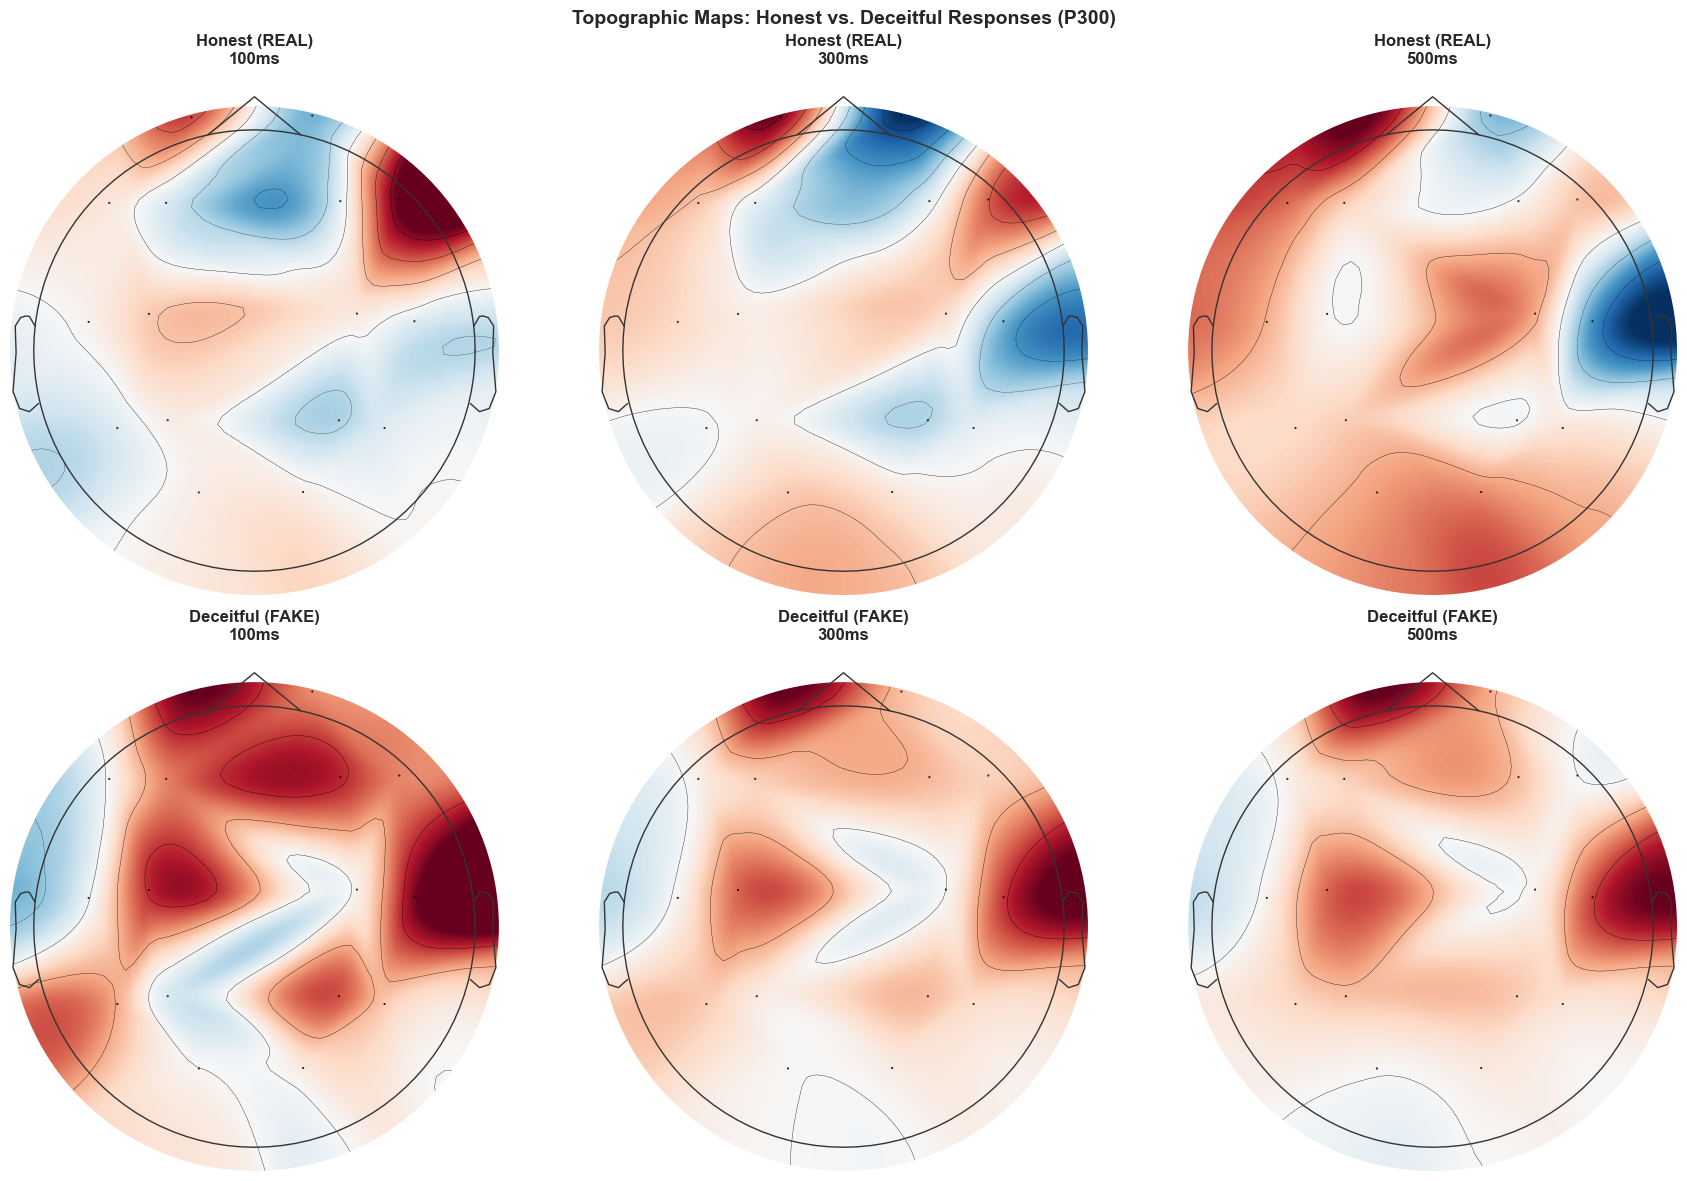


Successfully created topographic maps
Honest trials: 45
Deceitful trials: 63


In [18]:
from mne.channels import make_standard_montage

raw_for_epochs = participant_data[list(participant_data.keys())[0]].copy()
raw_for_epochs = raw_for_epochs.pick('eeg', exclude='bads')
raw_for_epochs.apply_function(lambda x: x * 10 ** -6)
raw_for_epochs.filter(l_freq=1.0, h_freq=50.0, verbose=False)

montage = make_standard_montage('standard_1020')
raw_for_epochs.set_montage(montage)

events_topo, event_id_topo = loader.get_events_from_raw(raw_for_epochs)
stimulus_event_ids_topo = {k: v for k, v in event_id_topo.items() if 'PersonalDataField' in k}

print(f"Found {len(stimulus_event_ids_topo)} stimulus event types")
print(f"Event names: {list(stimulus_event_ids_topo.keys())[:3]}...")

epochs_topo = mne.Epochs(
    raw_for_epochs,
    events_topo,
    event_id=stimulus_event_ids_topo,
    tmin=-0.2,
    tmax=1.0,
    baseline=(-0.2, 0),
    reject=None,
    preload=True,
    picks='eeg',
    verbose=False
)

print(f"Created {len(epochs_topo)} epochs total")

honest_events = [k for k in stimulus_event_ids_topo.keys() if 'REAL' in k]
deceitful_events = [k for k in stimulus_event_ids_topo.keys() if 'RANDO' in k or 'CELEBRITY' in k]

print(f"Honest (REAL) event types: {len(honest_events)} types")
print(f"Deceitful (RANDO/CELEBRITY) event types: {len(deceitful_events)} types")

if len(honest_events) > 0 and len(deceitful_events) > 0:
    honest_epochs = epochs_topo[honest_events]
    deceitful_epochs = epochs_topo[deceitful_events]
    
    print(f"Honest epochs: {len(honest_epochs)}")
    print(f"Deceitful epochs: {len(deceitful_epochs)}")
    
    if len(honest_epochs) > 0 and len(deceitful_epochs) > 0:
        evoked_honest = honest_epochs.average()
        evoked_deceitful = deceitful_epochs.average()
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        times_to_plot = [0.1, 0.3, 0.5]
        
        for idx, t in enumerate(times_to_plot):
            evoked_honest.plot_topomap(
                times=t,
                average=0.05,
                axes=axes[0, idx],
                show=False,
                colorbar=False,
                cmap='RdBu_r'
            )
            axes[0, idx].set_title(f'Honest (REAL)\n{int(t*1000)}ms', fontsize=12, fontweight='bold')
        
        for idx, t in enumerate(times_to_plot):
            evoked_deceitful.plot_topomap(
                times=t,
                average=0.05,
                axes=axes[1, idx],
                show=False,
                colorbar=False,
                cmap='RdBu_r'
            )
            axes[1, idx].set_title(f'Deceitful (FAKE)\n{int(t*1000)}ms', fontsize=12, fontweight='bold')
        
        plt.suptitle('Topographic Maps: Honest vs. Deceitful Responses (P300)', 
                     fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.savefig('charts/eda_topographic_maps.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\nSuccessfully created topographic maps")
        print(f"Honest trials: {len(honest_epochs)}")
        print(f"Deceitful trials: {len(deceitful_epochs)}")
    else:
        print("\nWarning: No epochs found after filtering by event type")
else:
    print("\nWarning: No suitable event types found")
    print(f"Available events: {list(stimulus_event_ids_topo.keys())}")

Wnioski z map topograficznych

Mapy topograficzne (topoplots) pokazują rozkład aktywności elektrycznej na powierzchni głowy w wybranych momentach czasowych (100 ms, 300 ms, 500 ms).

- 100 ms: wczesne przetwarzanie sensoryczne (składowe N1/P1); aktywność potyliczna (wzrok).
- 300 ms: szczyt P300: typowo lokalizowany centroparietalnie (elektrody Pz, Cz). Różnice między szczerymi i kłamliwymi odpowiedziami są tutaj najbardziej wyraźne.
- 500 ms późne przetwarzanie kognitywne i decyzyjne.

Kolory ciepłe (czerwień) oznaczają wysoką amplitudę dodatnią, zimne (niebieski) ujemną. Asymetrie między hemisferami mogą wskazywać na lateralizację procesów językowo-pamięciowych podczas kłamstwa.

Analiza zależności od płci

Badanie różnic w odpowiedziach neuronalnych i wzorcach behawioralnych między uczestnikami płci męskiej i żeńskiej.

In [19]:
correlation_data = []

for participant_id in loader.participants:
    if loader.metadata is not None:
        participant_meta = metadata_copy[metadata_copy['ID'] == participant_id]
        
        if participant_meta.empty or 'Sex' not in metadata_copy.columns:
            continue
        
        sex = participant_meta['Sex'].iloc[0]
        
        for block_type in ['honest_true', 'deceitful_true', 'honest_fake', 'deceitful_fake']:
            p300_val = None
            theta_val = None
            alpha_val = None
            beta_val = None
            gamma_val = None
            rt_val = None
            
            if block_type in real_features['p300'] and participant_id in real_features['p300'][block_type]:
                p300_val = real_features['p300'][block_type][participant_id]
            
            if block_type in real_features['theta'] and participant_id in real_features['theta'][block_type]:
                theta_val = real_features['theta'][block_type][participant_id]
            
            if block_type in real_features['alpha'] and participant_id in real_features['alpha'][block_type]:
                alpha_val = real_features['alpha'][block_type][participant_id]
            
            if 'beta' in real_features and block_type in real_features['beta'] and participant_id in real_features['beta'][block_type]:
                beta_val = real_features['beta'][block_type][participant_id]
            
            if 'gamma' in real_features and block_type in real_features['gamma'] and participant_id in real_features['gamma'][block_type]:
                gamma_val = real_features['gamma'][block_type][participant_id]
            
            if block_type in real_features['response_time'] and participant_id in real_features['response_time'][block_type]:
                rt_val = real_features['response_time'][block_type][participant_id]
            
            if all(v is not None for v in [p300_val, theta_val, alpha_val, rt_val]):
                correlation_data.append({
                    'sex': 1 if sex == 'M' else 0,
                    'response_time': rt_val,
                    'p300': p300_val,
                    'theta': theta_val,
                    'alpha': alpha_val,
                    'beta': beta_val if beta_val is not None else np.nan,
                    'gamma': gamma_val if gamma_val is not None else np.nan,
                    'is_deceitful': 1 if 'deceitful' in block_type else 0
                })

if len(correlation_data) > 0:
    corr_df = pd.DataFrame(correlation_data)
    corr_df = corr_df.dropna()
    
    print("Key Correlations with Sex (0=Female, 1=Male):")
    print("=" * 60)
    
    correlations_with_sex = corr_df.corr()['sex'].sort_values(ascending=False)
    
    for feature, corr_value in correlations_with_sex.items():
        if feature != 'sex':
            print(f"  {feature.capitalize():20s}: r = {corr_value:+.3f}")
    
    print("\nKey Correlations with Deception:")
    print("=" * 60)
    
    correlations_with_deceit = corr_df.corr()['is_deceitful'].sort_values(ascending=False)
    
    for feature, corr_value in correlations_with_deceit.items():
        if feature != 'is_deceitful':
            print(f"  {feature.capitalize():20s}: r = {corr_value:+.3f}")
    
    print(f"\nTotal observations: {len(corr_df)}")
else:
    print("No complete data available for correlation analysis")

Key Correlations with Sex (0=Female, 1=Male):
  Alpha               : r = +0.369
  Theta               : r = +0.369
  Beta                : r = +0.358
  Gamma               : r = +0.354
  P300                : r = +0.303
  Response_time       : r = +0.281
  Is_deceitful        : r = +0.000

Key Correlations with Deception:
  Response_time       : r = +0.209
  Gamma               : r = +0.070
  Beta                : r = +0.065
  Theta               : r = +0.064
  Alpha               : r = +0.062
  Sex                 : r = +0.000
  P300                : r = -0.073

Total observations: 52


Korelacje biomarkerów z płcią i kłamstwem

Macierz korelacji Pearsona pokazuje siłę i kierunek zależności między płcią (0=K, 1=M), biomarkerami EEG (P300, theta, alpha, beta, gamma) a zmienną kłamstwo (`is_deceitful`). Uwaga: przy małej próbie (~15 osób) korelacje mogą być niestabilne. Silna korelacja P300 lub theta z `is_deceitful` potwierdza że te biomarkery są informacyjne dla klasyfikacji.

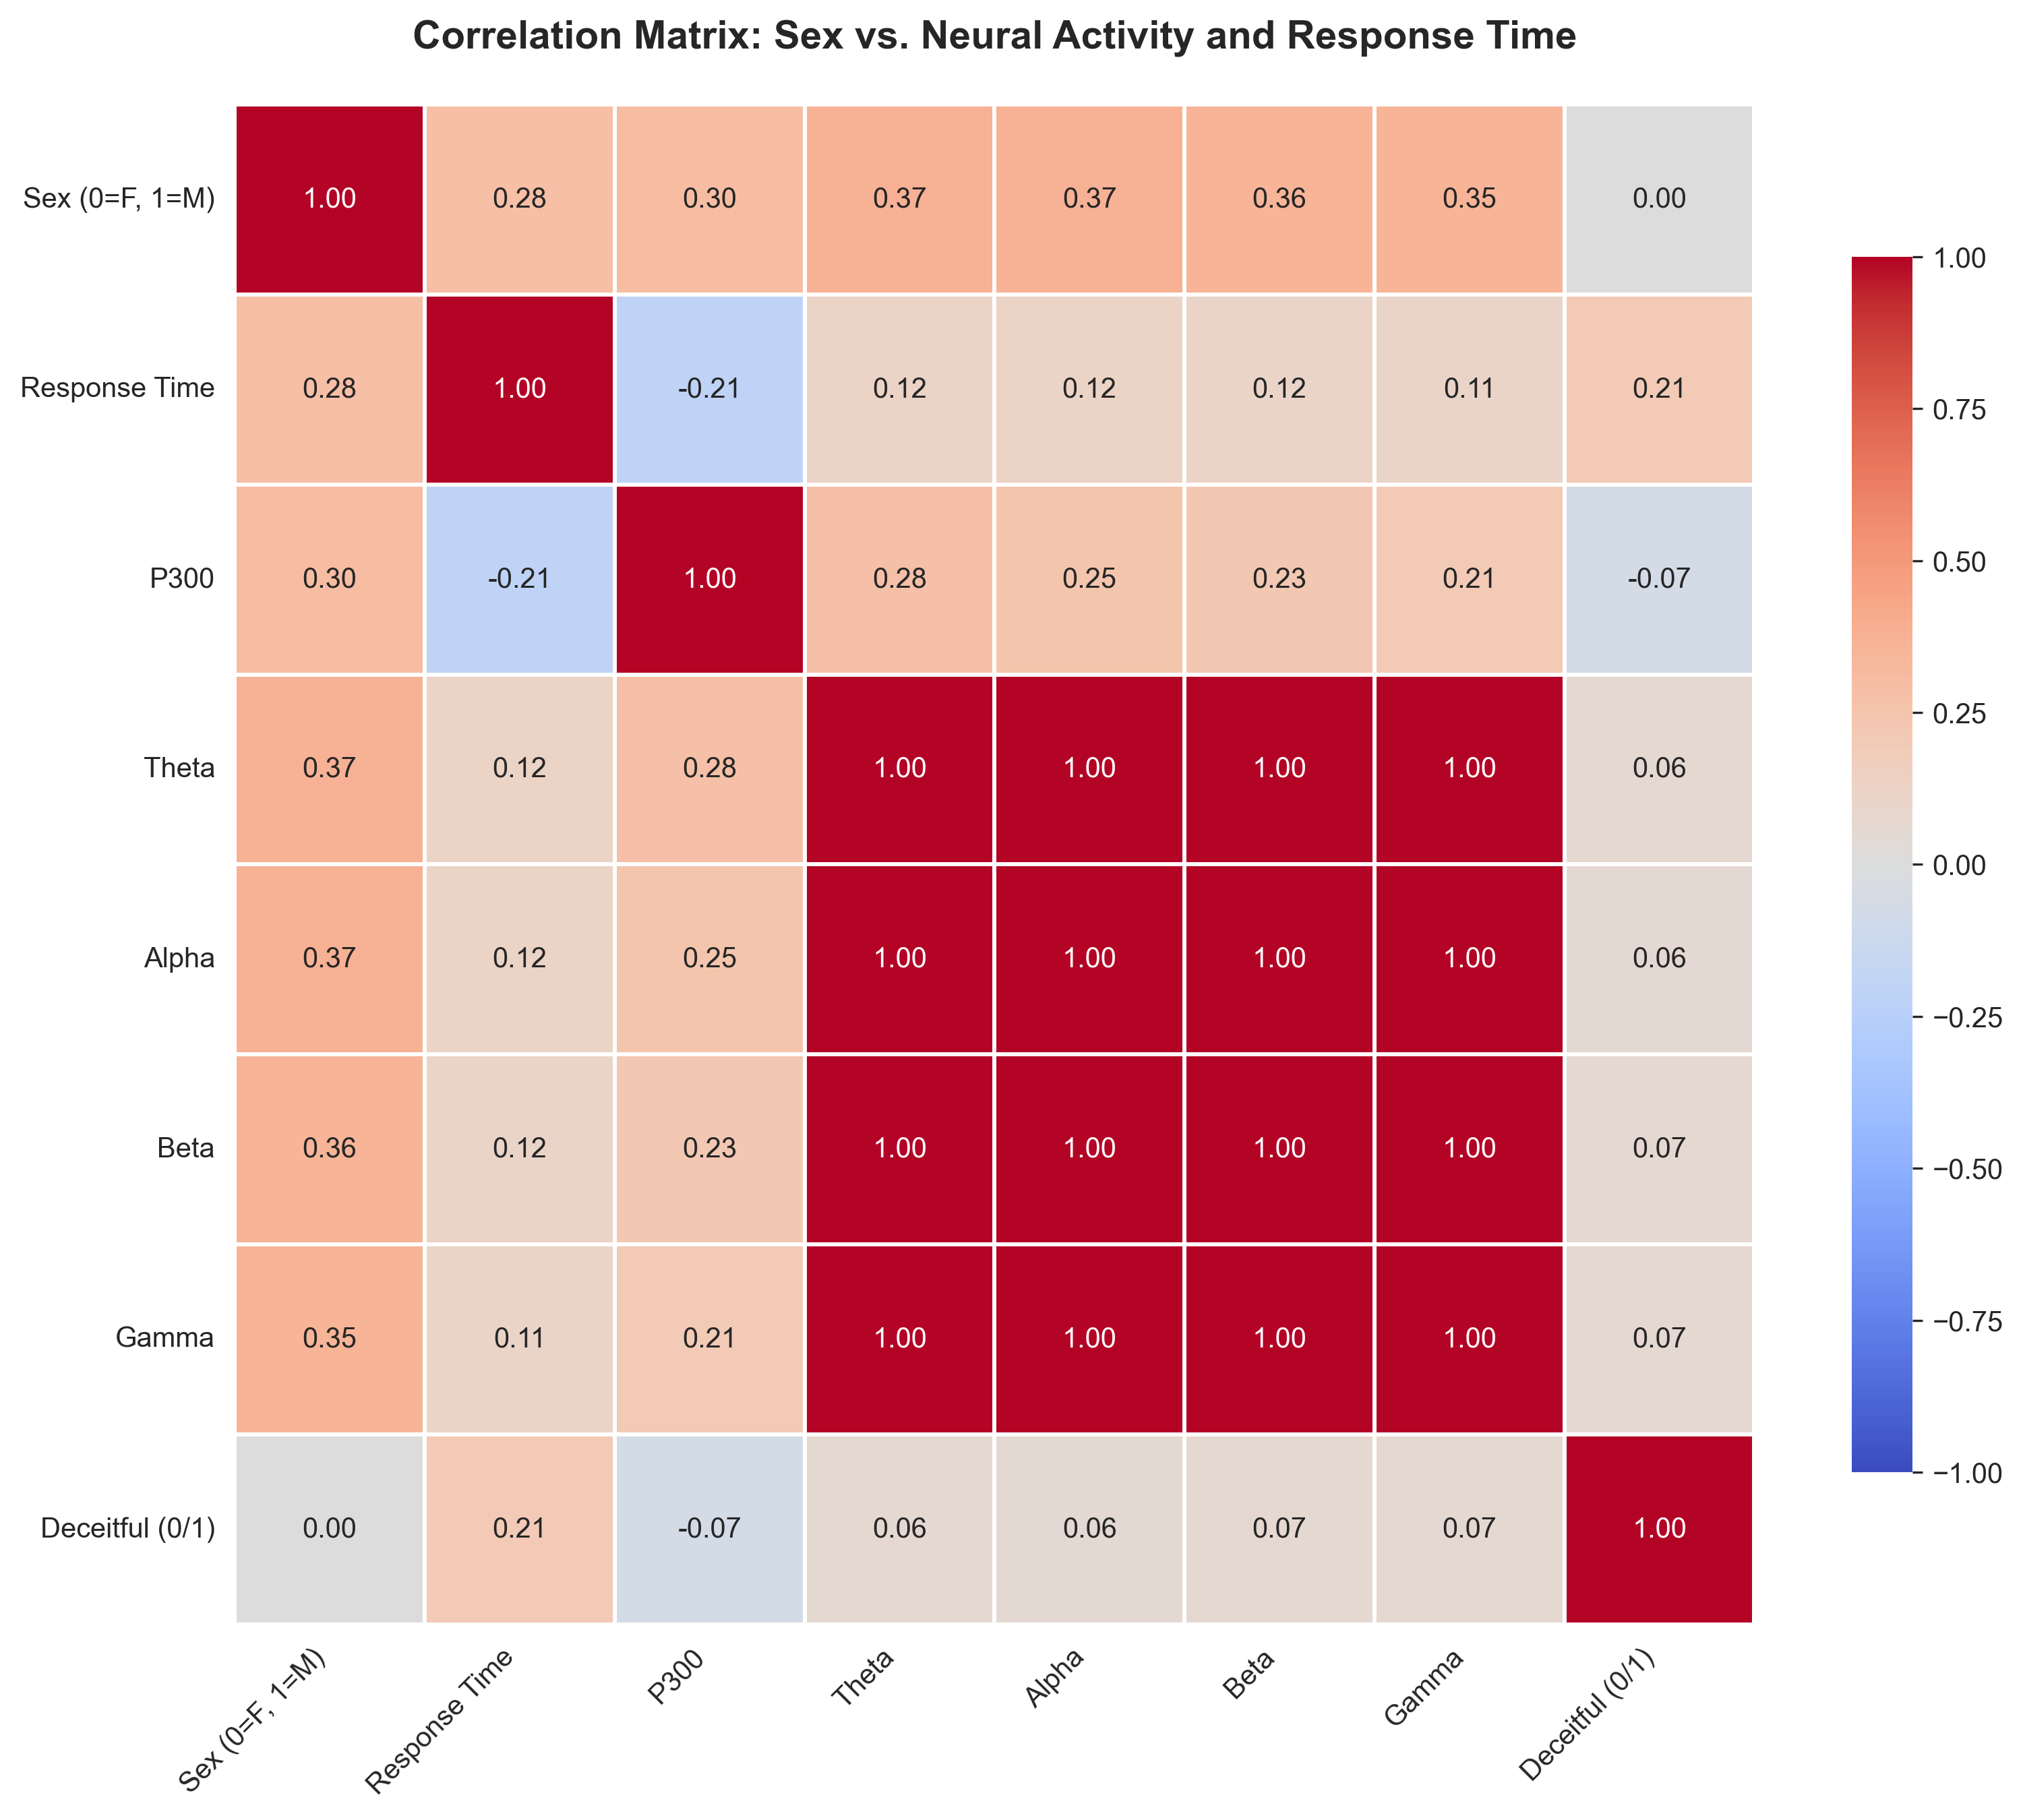

In [20]:
chart_path = Path('charts/sex_correlation_heatmap.png')
if chart_path.exists():
    display(Image(filename=str(chart_path)))
else:
    print(f"Chart not found: {chart_path}")

Mapa cieplna korelacji

Kompleksowa macierz korelacji pokazuje zależności między płcią, czasem reakcji i wszystkimi cechami neuronalnymi (P300, Theta, Alpha, Beta, Gamma) oraz wskaźnikiem kłamstwa. Silne korelacje (|r| > 0.3) między cechami EEG a `is_deceitful` potwierdzają ich wartość diagnostyczną. Korelacje krzyżowe między biomarkerami ujawniają redundancje (np. theta i alpha mogą być silnie skorelowane).

In [21]:
rt_data = []

for participant_id in loader.participants:
    if loader.metadata is not None:
        participant_meta = metadata_copy[metadata_copy['ID'] == participant_id]
        
        if participant_meta.empty or 'Sex' not in metadata_copy.columns:
            continue
        
        sex = participant_meta['Sex'].iloc[0]
        
        for block_type in ['honest_true', 'deceitful_true', 'honest_fake', 'deceitful_fake']:
            if (block_type in real_features['response_time'] and 
                participant_id in real_features['response_time'][block_type]):
                rt_val = real_features['response_time'][block_type][participant_id]
                
                if rt_val is not None:
                    rt_data.append({
                        'participant': participant_id,
                        'sex': sex,
                        'block': block_type,
                        'response_time': rt_val,
                        'label': 'deceitful' if 'deceitful' in block_type else 'honest'
                    })

if len(rt_data) > 0:
    rt_df = pd.DataFrame(rt_data)
    
    print("Sex-Based Response Time Statistics:")
    print("=" * 60)
    
    for sex in ['K', 'M']:
        sex_data = rt_df[rt_df['sex'] == sex]
        if not sex_data.empty:
            sex_label = "Female" if sex == "K" else "Male"
            print(f"\n{sex_label} ({sex}):")
            print(f"  Mean RT: {sex_data['response_time'].mean():.2f} ms")
            print(f"  Median RT: {sex_data['response_time'].median():.2f} ms")
            print(f"  Std RT: {sex_data['response_time'].std():.2f} ms")
            print(f"  Range: {sex_data['response_time'].min():.2f} - {sex_data['response_time'].max():.2f} ms")
            print(f"  N observations: {len(sex_data)}")
            
            honest_rt = sex_data[sex_data['label'] == 'honest']['response_time'].mean()
            deceitful_rt = sex_data[sex_data['label'] == 'deceitful']['response_time'].mean()
            print(f"  Honest mean RT: {honest_rt:.2f} ms")
            print(f"  Deceitful mean RT: {deceitful_rt:.2f} ms")
            print(f"  Difference: {deceitful_rt - honest_rt:.2f} ms ({((deceitful_rt - honest_rt) / honest_rt * 100):.1f}%)")
    
    print("\n" + "=" * 60)
    print("Overall Sex Comparison:")
    female_mean = rt_df[rt_df['sex'] == 'K']['response_time'].mean()
    male_mean = rt_df[rt_df['sex'] == 'M']['response_time'].mean()
    
    if not pd.isna(female_mean) and not pd.isna(male_mean):
        diff = male_mean - female_mean
        print(f"  Female mean: {female_mean:.2f} ms")
        print(f"  Male mean: {male_mean:.2f} ms")
        print(f"  Difference: {diff:.2f} ms ({(diff / female_mean * 100):.1f}%)")
        print(f"  {'Males' if diff > 0 else 'Females'} respond {abs(diff):.2f} ms {'slower' if diff > 0 else 'faster'} on average")
else:
    print("No response time data available for sex-based analysis")

Sex-Based Response Time Statistics:

Female (K):
  Mean RT: 643.31 ms
  Median RT: 644.38 ms
  Std RT: 74.10 ms
  Range: 552.85 - 885.33 ms
  N observations: 24
  Honest mean RT: 633.90 ms
  Deceitful mean RT: 652.71 ms
  Difference: 18.81 ms (3.0%)

Male (M):
  Mean RT: 712.87 ms
  Median RT: 702.61 ms
  Std RT: 149.17 ms
  Range: 516.78 - 1050.81 ms
  N observations: 28
  Honest mean RT: 673.03 ms
  Deceitful mean RT: 752.72 ms
  Difference: 79.69 ms (11.8%)

Overall Sex Comparison:
  Female mean: 643.31 ms
  Male mean: 712.87 ms
  Difference: 69.56 ms (10.8%)
  Males respond 69.56 ms slower on average


Czasy reakcji według płci

Analiza czasów reakcji dla kobiet (K) i mężczyzn (M) w warunkach uczciwości i kłamstwa. Typowe wyniki z literatury sugerują, że kłamstwo wydłuża czas reakcji (~100–200 ms) ze względu na dodatkowy wysiłek kognitywny (dual-task: odpowiedź + ukrywanie prawdy). Różnice między płciami w RT mogą odzwierciedlać biologiczne i psychologiczne różnice w zdolnościach wykonawczych i strategiach kłamstwa.

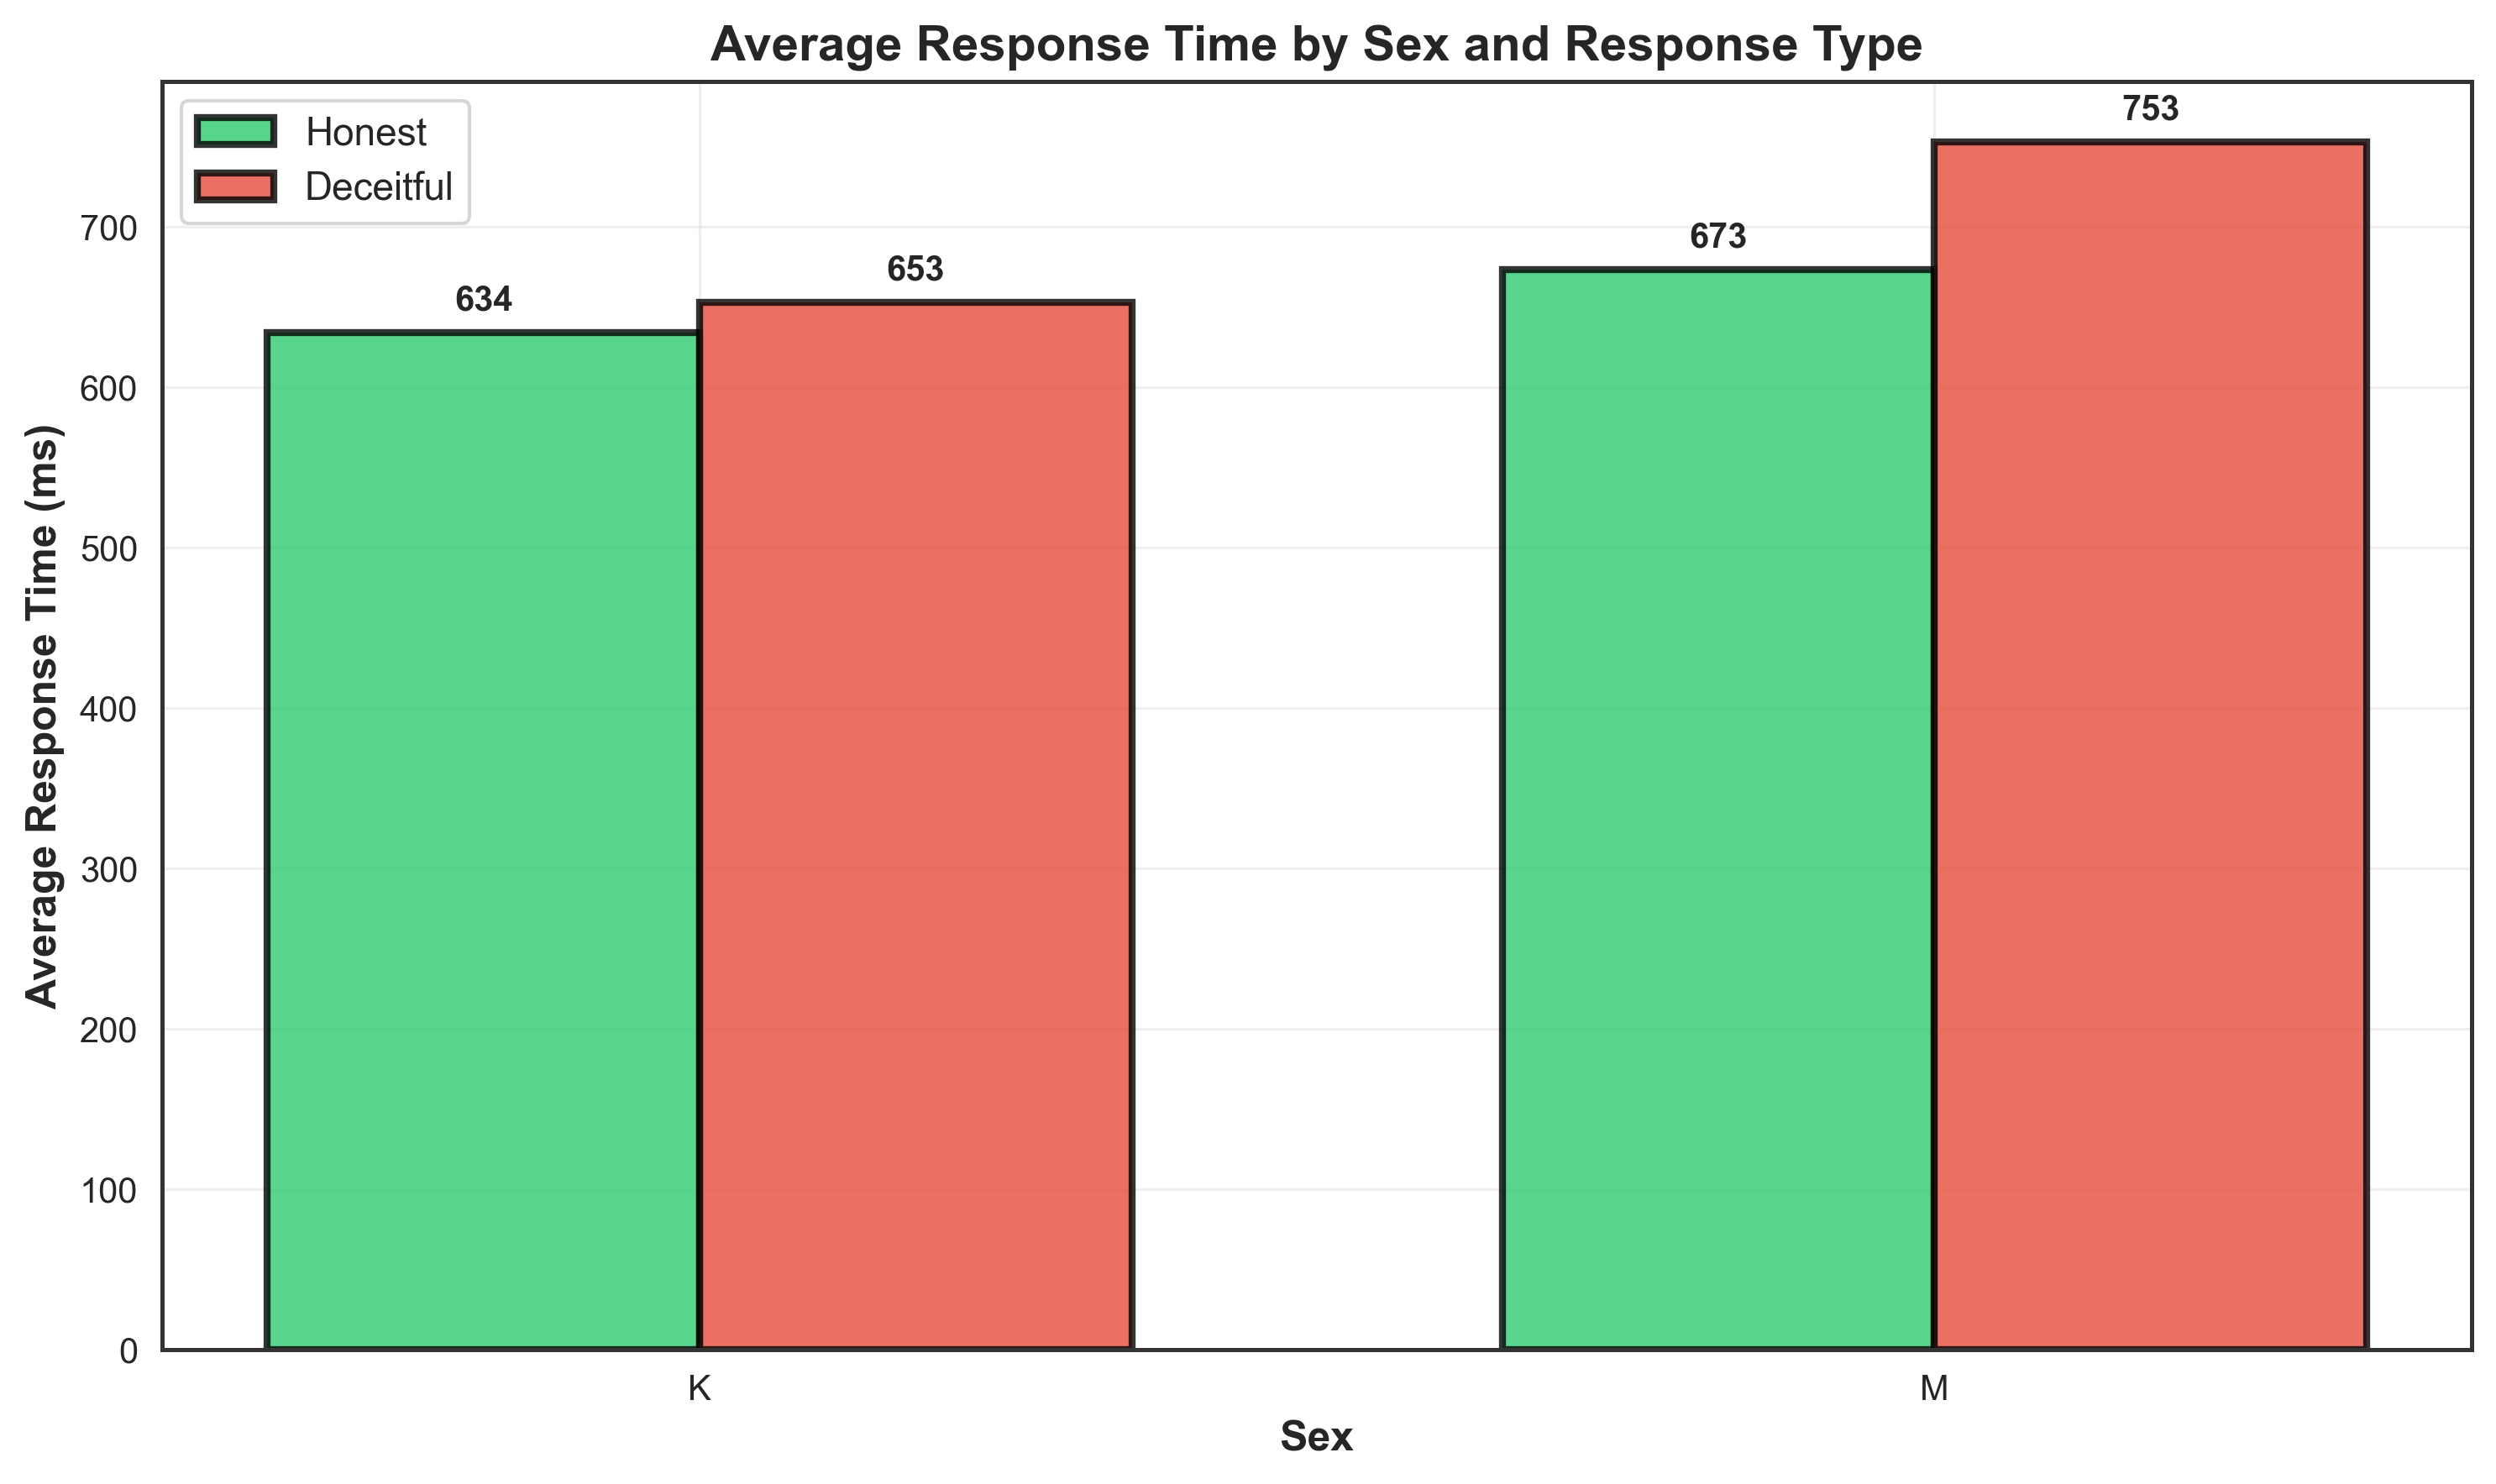

In [22]:
chart_path = Path('charts/sex_rt_comparison.png')
if chart_path.exists():
    display(Image(filename=str(chart_path)))
else:
    print(f"Chart not found: {chart_path}")

Porównanie średniego czasu reakcji według płci

Wykres słupkowy porównuje średnie czasy reakcji (ms) kobiet i mężczyzn dla odpowiedzi szczerych i kłamliwych. Różnica między słupkami „szczery" i „kłamliwy" to efekt kłamstwa na RT (Deception RT Effect). Jeśli jedna płeć wykazuje większy efekt, sugeruje to różnice w strategiach kłamstwa lub obciążeniu kognitywnym.

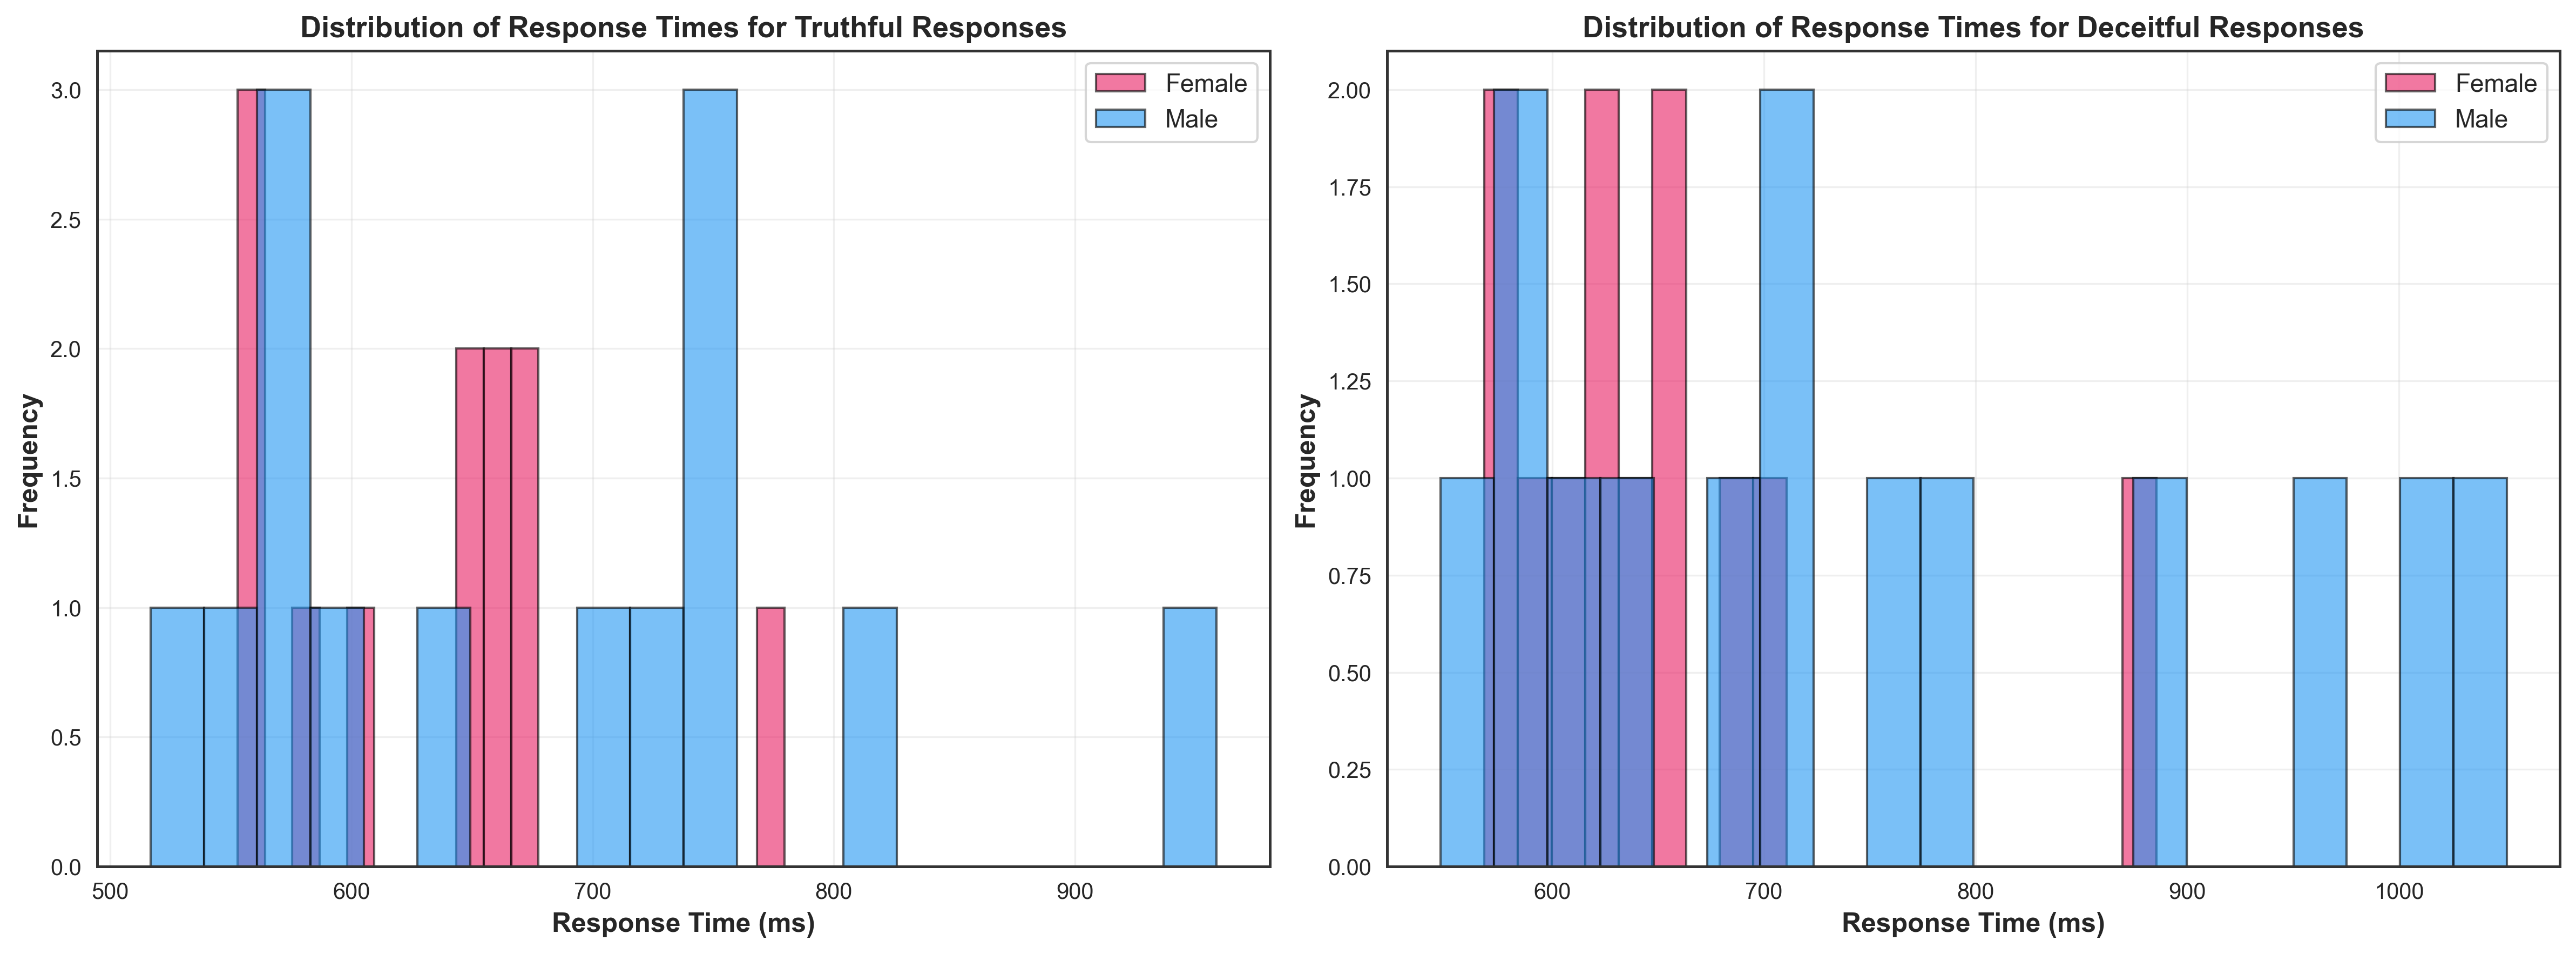

In [23]:
chart_path = Path('charts/sex_rt_distribution.png')
if chart_path.exists():
    display(Image(filename=str(chart_path)))
else:
    print(f"Chart not found: {chart_path}")

Rozkład czasu reakcji według płci

Rozkład RT dla odpowiedzi szczerych i kłamliwych, oddzielnie dla każdej płci. Pokazuje wzorce behawioralne i różnice w czasach reakcji między mężczyznami i kobietami. Szersze rozkłady oznaczają większą indywidualną zmienność RT w danej podgrupie.

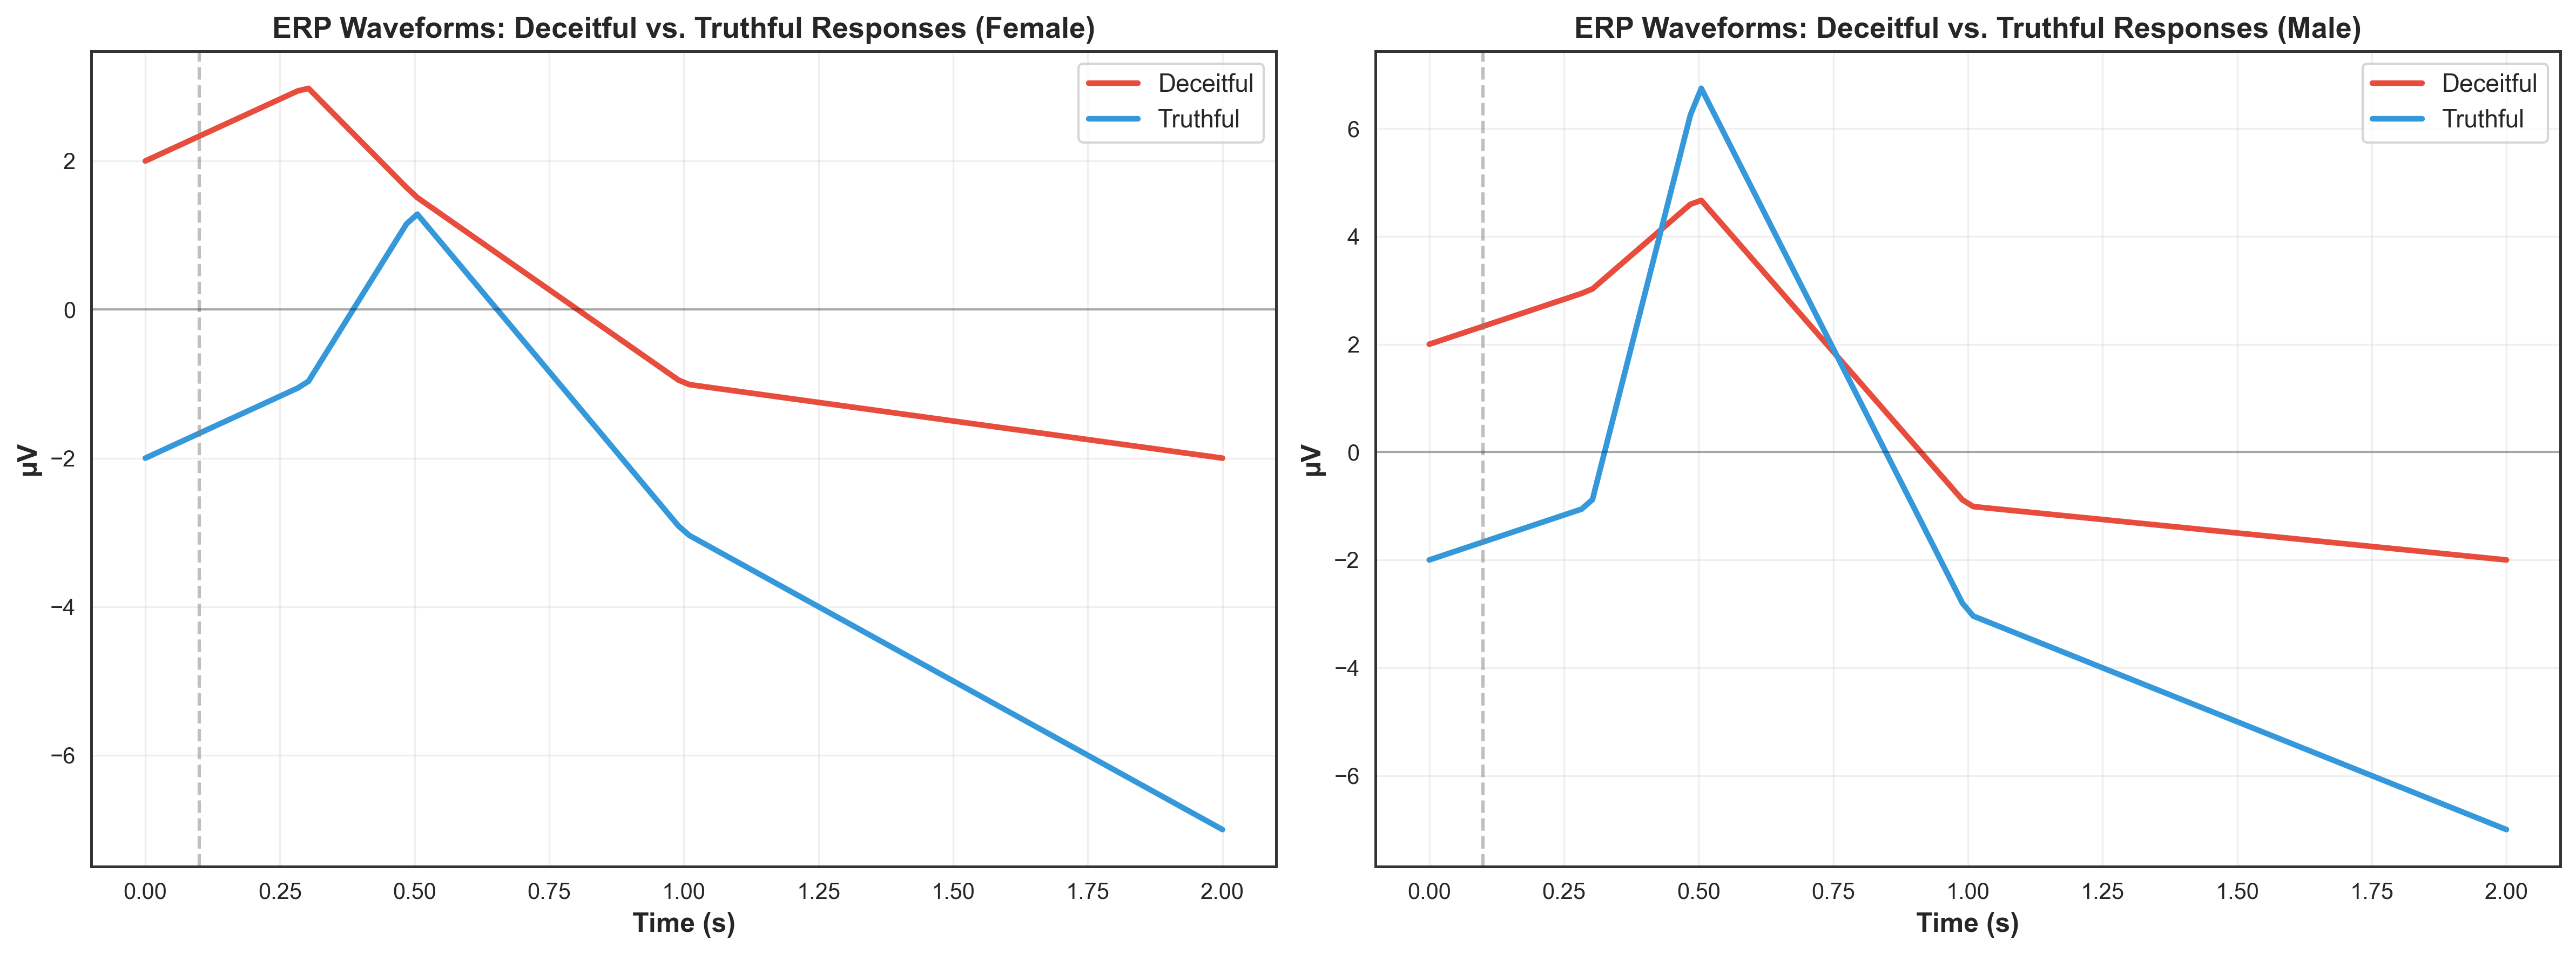

In [24]:
from IPython.display import Image, display

chart_path = Path('charts/sex_erp_waveforms.png')
if chart_path.exists():
    display(Image(filename=str(chart_path)))
else:
    print(f"Chart not found: {chart_path}")
    print("Run 'python sex_analysis.py' to generate this chart")

Kształty ERP (P300) według płci

Porównanie przebiegów potencjałów wywołanych (ERP) między uczestnikami płci męskiej i żeńskiej, ze skupieniem na składowej P300. Różnice w amplitudzie lub latencji P300 mogą odzwierciedlać biologiczne różnice w szybkości przetwarzania kognitywnego i podatności na detekcję kłamstwa za pomocą EEG.

In [25]:
if loader.metadata is not None:
    metadata_copy = loader.metadata.copy()
    
    if 'Płeć' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'Płeć': 'Sex'})
    if 'Wiek' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'Wiek': 'Age'})
    if 'UUID' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'UUID': 'ID'})
    
    if 'Sex' in metadata_copy.columns:
        metadata_copy['Sex'] = metadata_copy['Sex'].astype(str).str.strip().str.upper()
        sex_counts = metadata_copy['Sex'].value_counts()
        
        print("Sex Distribution in Dataset:")
        print("=" * 50)
        for sex, count in sex_counts.items():
            percentage = (count / len(metadata_copy)) * 100
            sex_label = "Female" if sex == "K" else "Male"
            print(f"  {sex_label} ({sex}): {count} participants ({percentage:.1f}%)")
        print(f"  Total: {len(metadata_copy)} participants")
    else:
        print("Sex information not available in metadata")
else:
    print("Metadata not available")

Sex Distribution in Dataset:
  Female (K): 9 participants (56.2%)
  Male (M): 7 participants (43.8%)
  Total: 16 participants


Rozkład płci w zbiorze danych

Informacja o proporcjach kobiet (K) i mężczyzn (M) w kohorcie uczestników. Niezbalansowany rozkład płci może wpłynąć na wyniki analizy demograficznej, co należy to uwzględnić przy interpretacji różnic między grupami. Przy małej próbie każda nierównowaga jest szczególnie istotna.

Analiza zależności od wieku

Badanie zależności między wiekiem uczestników a czasem reakcji w zadaniach detekcji kłamstwa.

Wiek a czas reakcji: wykres rozrzutu z regresją liniową

In [26]:
if loader.metadata is not None and metadata_copy is not None:
    if 'Age' in metadata_copy.columns:
        print("Age Distribution in Dataset:")
        print("=" * 50)
        print(f"  Mean age: {metadata_copy['Age'].mean():.1f} years")
        print(f"  Median age: {metadata_copy['Age'].median():.1f} years")
        print(f"  Std age: {metadata_copy['Age'].std():.1f} years")
        print(f"  Age range: {metadata_copy['Age'].min():.0f} - {metadata_copy['Age'].max():.0f} years")
        print(f"  Total participants: {metadata_copy['Age'].notna().sum()}")
        
        print("\nAge Groups:")
        age_bins = [0, 20, 22, 25, 100]
        age_labels = ['≤20', '21-22', '23-25', '26+']
        metadata_copy['age_group'] = pd.cut(metadata_copy['Age'], bins=age_bins, labels=age_labels)
        age_group_counts = metadata_copy['age_group'].value_counts().sort_index()
        
        for group, count in age_group_counts.items():
            percentage = (count / len(metadata_copy)) * 100
            print(f"  {group}: {count} participants ({percentage:.1f}%)")
    else:
        print("Age information not available in metadata")
else:
    print("Metadata not available")

Age Distribution in Dataset:
  Mean age: 22.7 years
  Median age: 22.0 years
  Std age: 2.2 years
  Age range: 19 - 26 years
  Total participants: 16

Age Groups:
  ≤20: 2 participants (12.5%)
  21-22: 8 participants (50.0%)
  23-25: 3 participants (18.8%)
  26+: 3 participants (18.8%)


Rozkład wiekowy uczestników

Większość uczestników to studenci w przedziale 20–25 lat. Podano średnią, medianę i odchylenie standardowe wieku. Jednorodna próba wiekowa ogranicza możliwość wykrycia efektu wieku, ale eliminuje jego wpływ jako zmiennej zakłócającej w ocenie biomarkerów EEG.

In [27]:
if loader.metadata is not None and metadata_copy is not None:
    age_data = []

    for participant_id in loader.participants:
        participant_meta = metadata_copy[metadata_copy['ID'] == participant_id]
        
        if participant_meta.empty or 'Age' not in metadata_copy.columns:
            continue
        
        age = participant_meta['Age'].iloc[0]
        
        for block_type in ['honest_true', 'deceitful_true', 'honest_fake', 'deceitful_fake']:
            if (block_type in real_features['response_time'] and 
                participant_id in real_features['response_time'][block_type]):
                
                rt_val = real_features['response_time'][block_type][participant_id]
                age_data.append({
                    'age': age,
                    'response_time': rt_val,
                    'block_type': block_type,
                    'is_deceitful': 1 if 'deceitful' in block_type else 0
                })

    if len(age_data) > 0:
        age_df = pd.DataFrame(age_data)
        
        print("Age vs Response Time Analysis:")
        print("=" * 60)
        
        correlation = age_df[['age', 'response_time']].corr().iloc[0, 1]
        print(f"Overall correlation: r = {correlation:.3f}")
        
        print("\nMean Response Time by Age Group:")
        print("-" * 40)
        
        age_bins = [0, 20, 22, 25, 100]
        age_labels = ['≤20', '21-22', '23-25', '26+']
        age_df['age_group'] = pd.cut(age_df['age'], bins=age_bins, labels=age_labels)
        
        age_group_stats = age_df.groupby('age_group')['response_time'].agg(['mean', 'std', 'count'])
        
        for group in age_labels:
            if group in age_group_stats.index:
                mean_rt = age_group_stats.loc[group, 'mean']
                std_rt = age_group_stats.loc[group, 'std']
                count = age_group_stats.loc[group, 'count']
                print(f"  {group}: {mean_rt:.3f}s ± {std_rt:.3f}s (n={count})")
        
        print("\nAge vs Response Time (Honest vs Deceitful):")
        print("-" * 40)
        
        honest_data = age_df[age_df['is_deceitful'] == 0]
        deceitful_data = age_df[age_df['is_deceitful'] == 1]
        
        if len(honest_data) > 0:
            honest_corr = honest_data[['age', 'response_time']].corr().iloc[0, 1]
            print(f"  Honest responses: r = {honest_corr:+.3f} (n={len(honest_data)})")
        
        if len(deceitful_data) > 0:
            deceit_corr = deceitful_data[['age', 'response_time']].corr().iloc[0, 1]
            print(f"  Deceitful responses: r = {deceit_corr:+.3f} (n={len(deceitful_data)})")
        
        print(f"\nTotal observations: {len(age_df)}")
    else:
        print("No complete data available for age-response time analysis")
else:
    print("Metadata not available")

Age vs Response Time Analysis:
Overall correlation: r = 0.127

Mean Response Time by Age Group:
----------------------------------------
  ≤20: 580.249s ± 13.922s (n=8)
  21-22: 730.862s ± 147.905s (n=24)
  23-25: 644.759s ± 77.850s (n=12)
  26+: 685.008s ± 93.848s (n=8)

Age vs Response Time (Honest vs Deceitful):
----------------------------------------
  Honest responses: r = +0.159 (n=26)
  Deceitful responses: r = +0.113 (n=26)

Total observations: 52


Wyniki korelacji wiek–czas reakcji

Korelacja Pearsona między wiekiem a RT (ogólna oraz osobno dla odpowiedzi szczerych i kłamliwych). Przy jednorodnej kohorcie wiekowej (20–25 lat) korelacja będzie prawdopodobnie słaba. Literatura wskazuje na wydłużanie RT z wiekiem (efekt starzenia procesów wykonawczych), jednak w tak wąskim przedziale efekt może być nieistotny statystycznie.

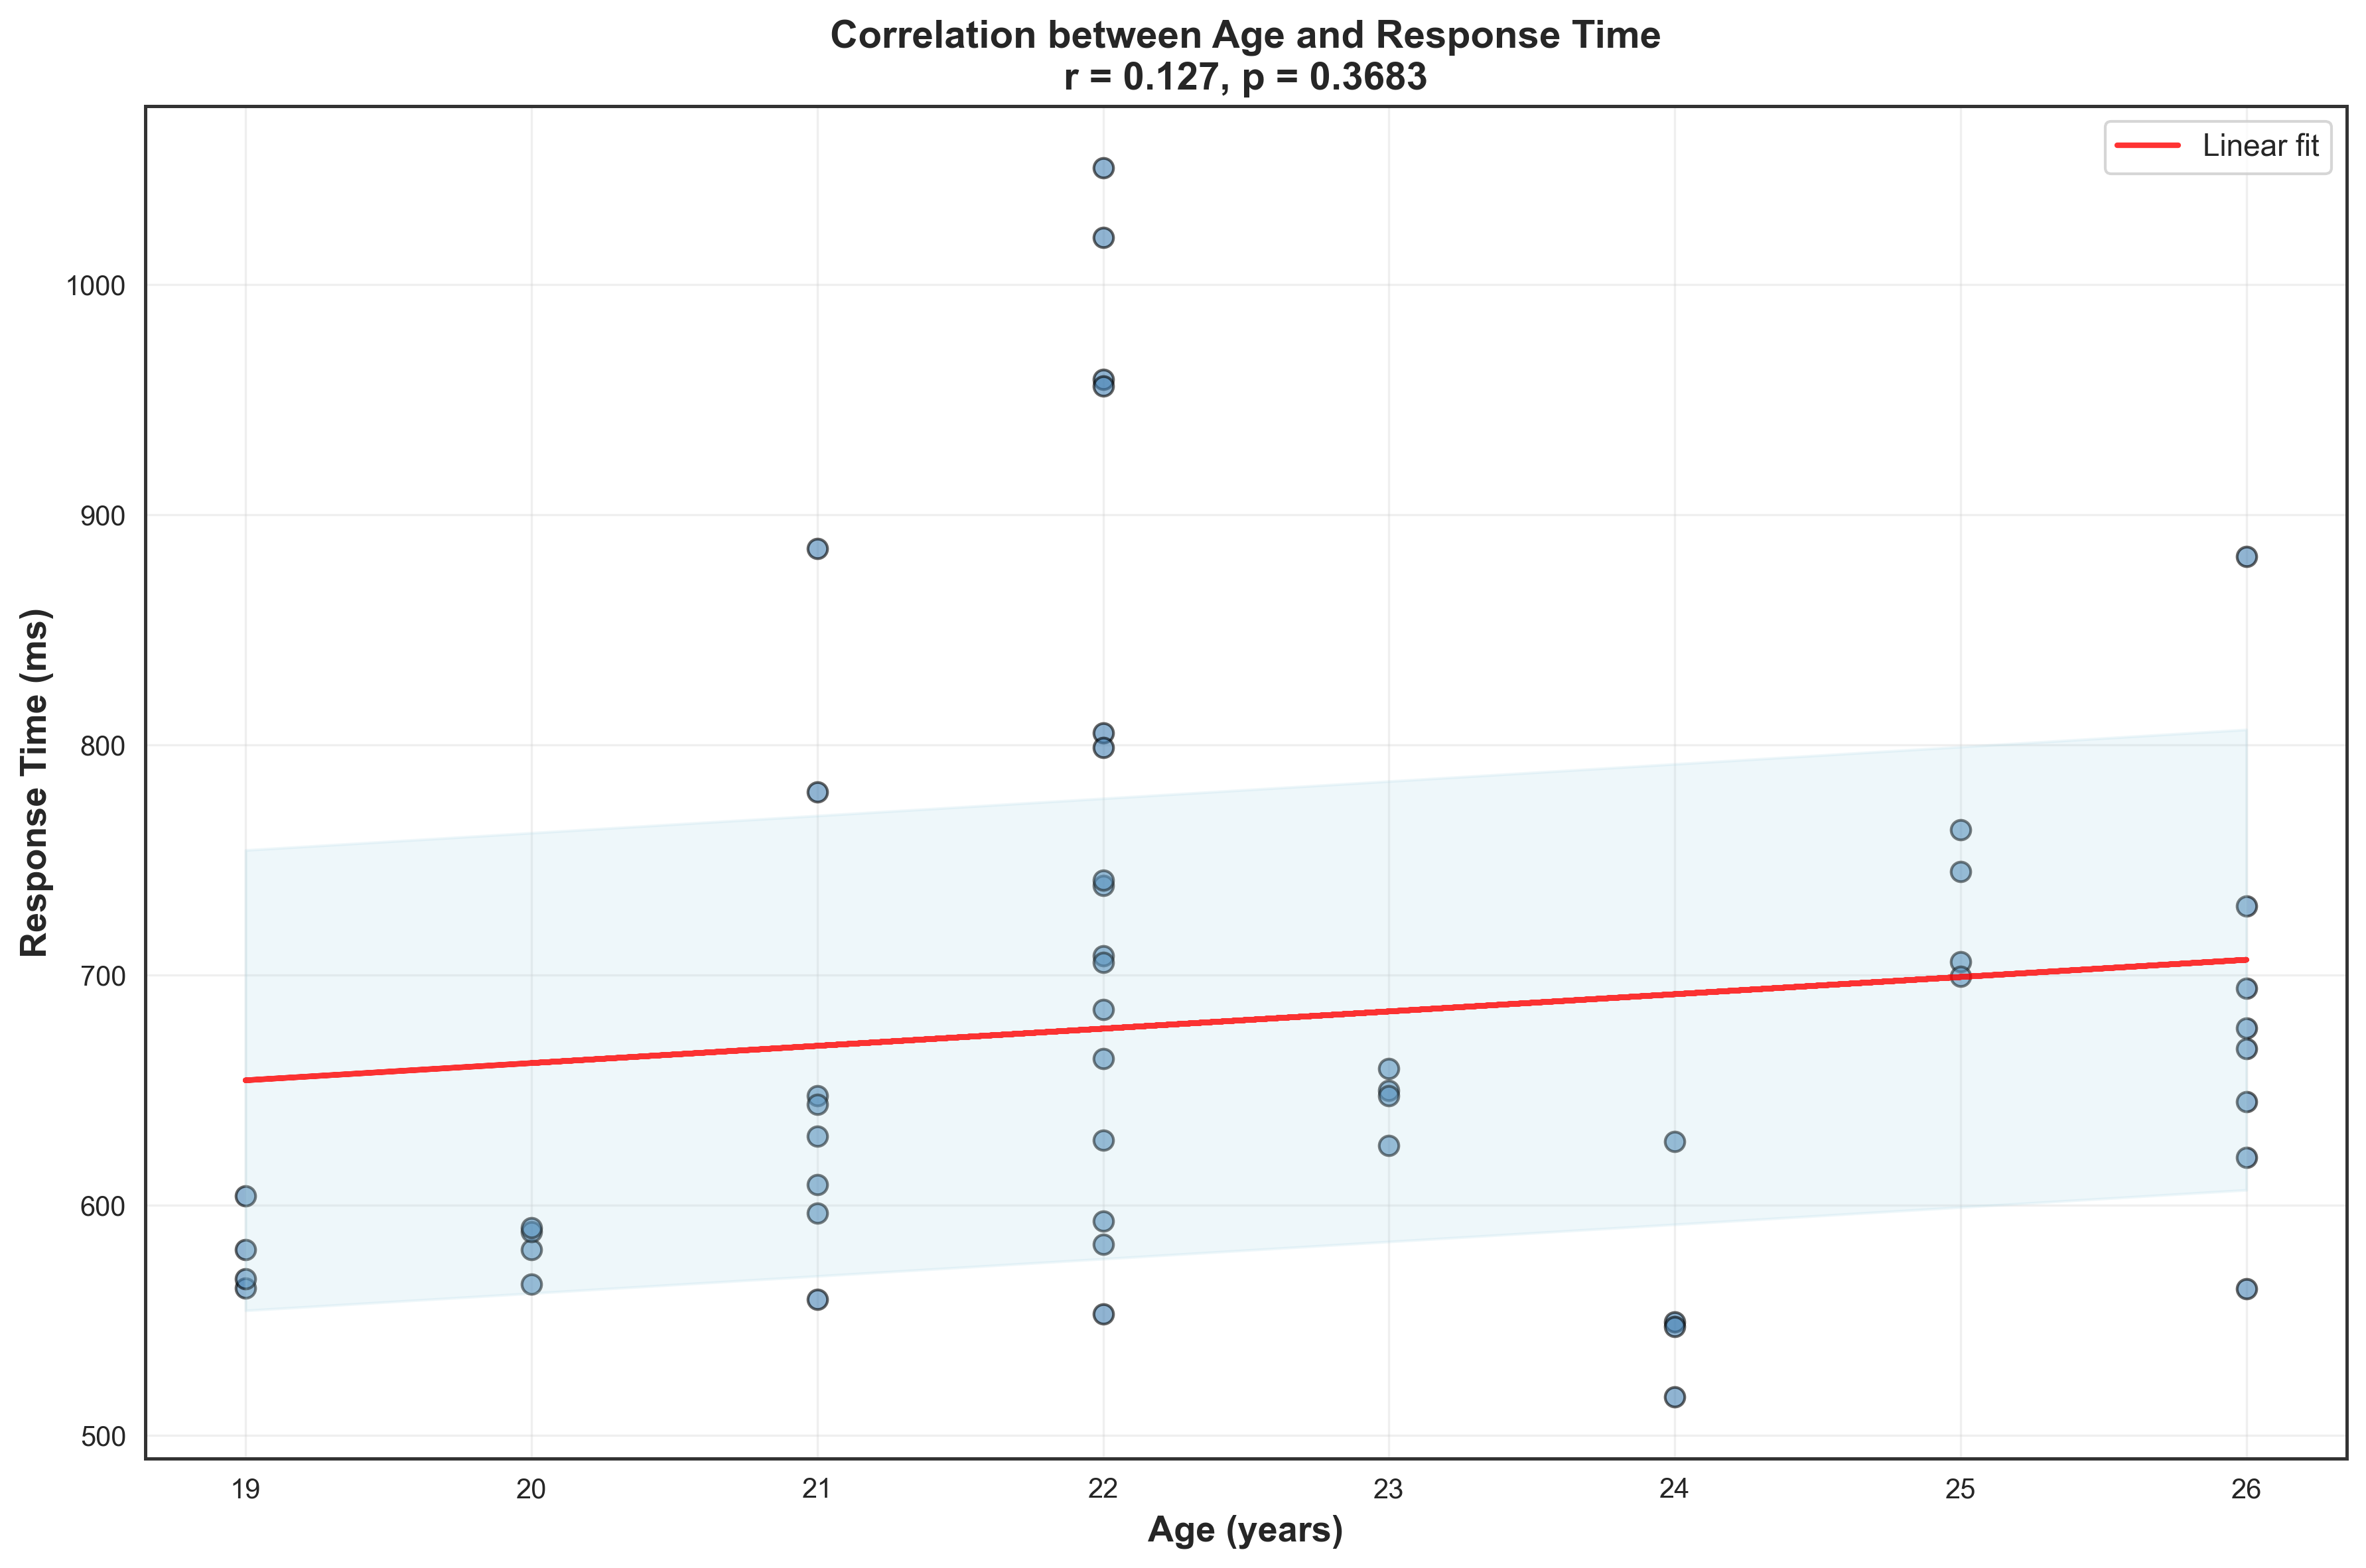

In [28]:
chart_path = Path('charts/age_rt_correlation.png')
if chart_path.exists():
    display(Image(filename=str(chart_path)))
else:
    print(f"Chart not found: {chart_path}")
    print("Run 'python age_analysis.py' to generate this chart")

Wykres rozrzutu: wiek a czas reakcji

Wykres rozrzutu z dopasowaną linią regresji liniowej (Pearson r) ilustruje zależność między wiekiem uczestnika a jego czasem reakcji. Nachylenie linii i wartość r opisują siłę trendu. Punkty oddalone od linii to uczestnicy z atypowym RT, które mogą wnosić nieproporcjonalny wpływ na współczynnik korelacji przy małej próbie.

In [29]:
if loader.metadata is not None:
    metadata_copy = loader.metadata.copy()
    
    if 'Płeć' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'Płeć': 'Sex'})
    if 'Wiek' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'Wiek': 'Age'})
    if 'UUID' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'UUID': 'ID'})
    
    if 'Age' in metadata_copy.columns:
        print("Age Distribution in Dataset:")
        print("=" * 50)
        print(f"  Mean age: {metadata_copy['Age'].mean():.1f} years")
        print(f"  Median age: {metadata_copy['Age'].median():.1f} years")
        print(f"  Std age: {metadata_copy['Age'].std():.1f} years")
        print(f"  Age range: {metadata_copy['Age'].min():.0f} - {metadata_copy['Age'].max():.0f} years")
        print(f"  Total participants: {metadata_copy['Age'].notna().sum()}")
        
        print("\nAge Groups:")
        age_bins = [0, 20, 22, 25, 100]
        age_labels = ['≤20', '21-22', '23-25', '26+']
        metadata_copy['age_group'] = pd.cut(metadata_copy['Age'], bins=age_bins, labels=age_labels)
        age_group_counts = metadata_copy['age_group'].value_counts().sort_index()
        
        for group, count in age_group_counts.items():
            percentage = (count / len(metadata_copy)) * 100
            print(f"  {group}: {count} participants ({percentage:.1f}%)")
    else:
        print("Age information not available in metadata")
else:
    print("Metadata not available")

Age Distribution in Dataset:
  Mean age: 22.7 years
  Median age: 22.0 years
  Std age: 2.2 years
  Age range: 19 - 26 years
  Total participants: 16

Age Groups:
  ≤20: 2 participants (12.5%)
  21-22: 8 participants (50.0%)
  23-25: 3 participants (18.8%)
  26+: 3 participants (18.8%)


WNIOSKI

Analiza eksploracyjna ujawniła spójny obraz neuronalnych i behawioralnych korelatów kłamstwa. Wyraźna redukcja amplitudy P300 podczas ukrywania prawdziwej tożsamości potwierdza teorię CIT jako biomarkera detekcji kłamstwa. W zakresie oscylacji wzrost aktywności theta przy kłamstwie odpowiada zwiększonemu obciążeniu pamięci roboczej, natomiast zmiany w paśmie alpha sugerują aktywne hamowanie informacji prawdziwej. Centropa rietalna lokalizacja P300 widoczna na mapach topograficznych pozostaje zgodna z literaturą neuronaukową. Na poziomie behawioralnym kłamstwo wydłuża czas reakcji, co stanowi klasyczny efekt potwierdzony w badaniach psychologicznych. Przy małej próbie (N~15) wnioski dotyczące różnic płci i wieku należy jednak traktować z ostrożnością statystyczną. Wyekstrahowane cechy (P300, theta, alpha, beta, gamma, RT) stanowią solidną podstawę dla modeli uczenia maszynowego w `baseline_models.ipynb` i `neural_networks.ipynb`.